
# Healthcare Readmission Analytics
## 03 — Exploratory Data Analysis

### Objective

This notebook explores the validated modeling dataset created during preprocessing to identify patterns associated with **30-day hospital readmission**.

The analysis focuses on:

- the prevalence and distribution of 30-day readmission,
- demographic patterns,
- healthcare-utilization and encounter characteristics,
- clinical and diagnostic characteristics,
- medication-related patterns,
- relationships between candidate predictors and readmission risk,
- and implications for downstream predictive modeling.

### Analytical safeguards

To preserve the integrity of downstream model evaluation:

- **Training data is used for exploratory relationship analysis and data-driven decisions.**
- Validation and test partitions remain protected from exploratory feature selection and model-development decisions.
- `patient_nbr` is retained only for patient-level grouping and validation.
- `encounter_id` is retained only as an encounter identifier.
- The original multiclass `readmitted` outcome is retained for traceability.
- `readmitted_30d` is the binary modeling target.

The processed datasets and feature metadata produced by Notebook 02 are treated as the authoritative inputs for this notebook.

In [1]:
# 3A — EDA setup and processed-data loading

from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

# Resolve project root whether the notebook kernel starts from the
# repository root or the notebooks directory.
cwd = Path.cwd().resolve()

if (cwd / "data" / "processed").exists():
    PROJECT_ROOT = cwd
elif (cwd.parent / "data" / "processed").exists():
    PROJECT_ROOT = cwd.parent
else:
    raise FileNotFoundError(
        "Could not locate data/processed from the current working directory."
    )

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

train_path = PROCESSED_DIR / "train.csv"
validation_path = PROCESSED_DIR / "validation.csv"
test_path = PROCESSED_DIR / "test.csv"
registry_path = PROCESSED_DIR / "feature_registry.json"

required_artifacts = [
    train_path,
    validation_path,
    test_path,
    registry_path,
]

missing_artifacts = [path.name for path in required_artifacts if not path.exists()]

assert not missing_artifacts, f"Missing processed artifacts: {missing_artifacts}"

df_train = pd.read_csv(train_path)
df_validation = pd.read_csv(validation_path)
df_test = pd.read_csv(test_path)

with registry_path.open("r", encoding="utf-8") as file:
    feature_registry = json.load(file)

TARGET = "readmitted_30d"
PATIENT_ID = "patient_nbr"
ENCOUNTER_ID = "encounter_id"
SOURCE_OUTCOME = "readmitted"

print("EDA environment initialized")
print("-" * 45)
print(f"Project root:     {PROJECT_ROOT}")
print(f"Processed data:   {PROCESSED_DIR}")
print()
print(f"Train:            {df_train.shape}")
print(f"Validation:       {df_validation.shape}")
print(f"Test:             {df_test.shape}")
print(f"Feature registry: loaded")

EDA environment initialized
---------------------------------------------
Project root:     C:\Users\amohe.000\Downloads\healthcare-readmission-analytics
Processed data:   C:\Users\amohe.000\Downloads\healthcare-readmission-analytics\data\processed

Train:            (71520, 48)
Validation:       (15027, 48)
Test:             (15219, 48)
Feature registry: loaded


### 3A.2 — Processed dataset integrity validation

Before exploratory analysis, the persisted train, validation, and test datasets are independently validated.

The checks confirm:

- identical schemas across partitions,
- presence and validity of the binary target,
- absence of missing values,
- uniqueness of encounter identifiers,
- complete separation of patients across partitions,
- consistency between the original readmission outcome and the derived 30-day target,
- and complete encounter coverage across the persisted datasets.

These checks ensure that exploratory analysis begins from the validated preprocessing state established in Notebook 02.

In [2]:
# Validate persisted dataset integrity before exploratory analysis

partitions = {
    "Train": df_train,
    "Validation": df_validation,
    "Test": df_test,
}

reference_columns = list(df_train.columns)

# Schema consistency
for name, frame in partitions.items():
    assert (
        list(frame.columns) == reference_columns
    ), f"{name} schema differs from training schema."

# Required protected columns
required_columns = {
    ENCOUNTER_ID,
    PATIENT_ID,
    SOURCE_OUTCOME,
    TARGET,
}

for name, frame in partitions.items():
    missing = required_columns - set(frame.columns)
    assert not missing, f"{name} missing required columns: {missing}"

# Missingness, target validity, and encounter uniqueness
for name, frame in partitions.items():
    assert frame.isna().sum().sum() == 0, f"{name} contains missing values."

    assert set(frame[TARGET].unique()) == {0, 1}, f"{name} target is not binary."

    assert frame[ENCOUNTER_ID].is_unique, f"{name} contains duplicate encounter IDs."

# Verify binary target against original source outcome
for name, frame in partitions.items():
    expected_target = frame[SOURCE_OUTCOME].eq("<30").astype("int8")

    assert np.array_equal(
        frame[TARGET].to_numpy(),
        expected_target.to_numpy(),
    ), f"{name} binary target disagrees with source outcome."

# Patient-disjoint partition validation
patient_sets = {name: set(frame[PATIENT_ID]) for name, frame in partitions.items()}

patient_overlap = {
    "train_validation": len(patient_sets["Train"] & patient_sets["Validation"]),
    "train_test": len(patient_sets["Train"] & patient_sets["Test"]),
    "validation_test": len(patient_sets["Validation"] & patient_sets["Test"]),
}

assert all(
    value == 0 for value in patient_overlap.values()
), f"Patient leakage detected: {patient_overlap}"

# Global encounter coverage
all_encounters = pd.concat(
    [frame[[ENCOUNTER_ID]] for frame in partitions.values()],
    ignore_index=True,
)

assert (
    len(all_encounters) == 101_766
), "Persisted partition row count does not equal the audited dataset."

assert (
    all_encounters[ENCOUNTER_ID].nunique() == 101_766
), "Encounter IDs are not globally unique across partitions."

# Compact validation summary
integrity_summary = pd.DataFrame(
    [
        {
            "partition": name,
            "rows": len(frame),
            "columns": frame.shape[1],
            "patients": frame[PATIENT_ID].nunique(),
            "positive_cases": int(frame[TARGET].sum()),
            "positive_rate": frame[TARGET].mean(),
            "missing_cells": int(frame.isna().sum().sum()),
            "duplicate_encounters": int(frame[ENCOUNTER_ID].duplicated().sum()),
        }
        for name, frame in partitions.items()
    ]
)

print("Processed-dataset integrity validation")
print("-" * 48)
print(f"Schema consistent:          True")
print(f"Target integrity:           True")
print(f"Missing cells:              0")
print(f"Encounter coverage:         {len(all_encounters):,}/101,766")
print(f"Global encounter uniqueness:{all_encounters[ENCOUNTER_ID].is_unique}")
print()
print("Patient overlap:")
for pair, count in patient_overlap.items():
    print(f"  {pair:<20} {count:,}")

print("\nValidation passed: processed EDA inputs are clean.")

integrity_summary

Processed-dataset integrity validation
------------------------------------------------
Schema consistent:          True
Target integrity:           True
Missing cells:              0
Encounter coverage:         101,766/101,766
Global encounter uniqueness:True

Patient overlap:
  train_validation     0
  train_test           0
  validation_test      0

Validation passed: processed EDA inputs are clean.


,partition,rows,columns,patients,positive_cases,positive_rate,missing_cells,duplicate_encounters
0,Train,71520,48,50062,8021,0.1122,0,0
1,Validation,15027,48,10728,1656,0.1102,0,0
2,Test,15219,48,10728,1680,0.1104,0,0


## 3B — Target Distribution and Class Balance

Exploratory analysis begins with the **training partition only**. Validation and test data are intentionally excluded from EDA to preserve their role as unbiased downstream evaluation datasets.

The primary modeling outcome is `readmitted_30d`, where:

- `1` = hospital readmission within 30 days
- `0` = no readmission within 30 days

This section quantifies the prevalence of 30-day readmission and evaluates the degree of class imbalance that downstream modeling will need to accommodate.

In [3]:
# Examine 30-day readmission target distribution using training data only

target_counts = df_train[TARGET].value_counts().sort_index()

target_distribution = pd.DataFrame(
    {
        "target": target_counts.index,
        "encounters": target_counts.values,
    }
)

target_distribution["label"] = target_distribution["target"].map(
    {
        0: "No 30-day readmission",
        1: "30-day readmission",
    }
)

target_distribution["percentage"] = (
    target_distribution["encounters"] / len(df_train) * 100
)

negative_count = int(target_counts.get(0, 0))
positive_count = int(target_counts.get(1, 0))

positive_rate = positive_count / len(df_train)
negative_rate = negative_count / len(df_train)
imbalance_ratio = negative_count / positive_count

print("Training target distribution")
print("-" * 45)
print(f"Training encounters:        {len(df_train):,}")
print(f"No 30-day readmission:     {negative_count:,} ({negative_rate:.2%})")
print(f"30-day readmission:        {positive_count:,} ({positive_rate:.2%})")
print(f"Negative : positive ratio: {imbalance_ratio:.2f} : 1")

assert negative_count + positive_count == len(df_train)
assert positive_count == int(df_train[TARGET].sum())
assert 0 < positive_rate < 1

target_distribution[["target", "label", "encounters", "percentage"]]

Training target distribution
---------------------------------------------
Training encounters:        71,520
No 30-day readmission:     63,499 (88.78%)
30-day readmission:        8,021 (11.22%)
Negative : positive ratio: 7.92 : 1


,target,label,encounters,percentage
0,0,No 30-day readmission,63499,88.7850
1,1,30-day readmission,8021,11.2150


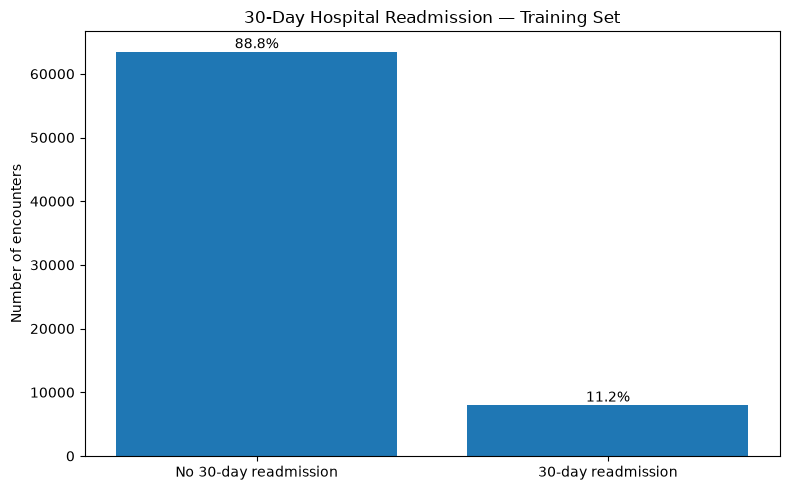

In [4]:
# Visualize training target distribution

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    target_distribution["label"],
    target_distribution["encounters"],
)

ax.set_title("30-Day Hospital Readmission — Training Set")
ax.set_xlabel("")
ax.set_ylabel("Number of encounters")

for bar, percentage in zip(bars, target_distribution["percentage"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{percentage:.1f}%",
        ha="center",
        va="bottom",
    )

plt.tight_layout()
plt.show()

### Interpretation

The training partition exhibits substantial class imbalance. Approximately **11.2% of encounters result in readmission within 30 days**, compared with **88.8% without 30-day readmission**, corresponding to roughly **7.9 non-readmitted encounters for every readmitted encounter**.

Consequently, classification accuracy alone will not provide an adequate measure of model performance. Downstream evaluation should emphasize metrics that reflect minority-class detection, including **recall, precision, F1 score, ROC-AUC, and precision-recall AUC (PR-AUC)**.

## 3C — Patient and Encounter Structure

The dataset is organized at the **hospital-encounter level**, meaning an individual patient may contribute multiple encounters.

This section examines the relationship between patients and encounters within the training partition. Understanding repeated utilization is important because patients with multiple hospital encounters may differ systematically from patients observed only once.

All analyses in this section continue to use the **training partition only**.

In [5]:
# Summarize patient-level encounter frequency in the training partition

patient_encounter_counts = df_train.groupby(PATIENT_ID).size().rename("encounter_count")

unique_train_patients = patient_encounter_counts.size
single_encounter_patients = int((patient_encounter_counts == 1).sum())
repeat_patients = int((patient_encounter_counts > 1).sum())

max_encounters = int(patient_encounter_counts.max())
mean_encounters = patient_encounter_counts.mean()
median_encounters = patient_encounter_counts.median()

repeat_patient_rate = repeat_patients / unique_train_patients

print("Training patient/encounter structure")
print("-" * 45)
print(f"Encounters:                 {len(df_train):,}")
print(f"Unique patients:            {unique_train_patients:,}")
print(f"Single-encounter patients:  {single_encounter_patients:,}")
print(f"Multi-encounter patients:   {repeat_patients:,}")
print(f"Multi-encounter rate:       {repeat_patient_rate:.2%}")
print(f"Mean encounters/patient:    {mean_encounters:.2f}")
print(f"Median encounters/patient:  {median_encounters:.0f}")
print(f"Maximum encounters/patient: {max_encounters:,}")

assert patient_encounter_counts.sum() == len(df_train)
assert unique_train_patients == df_train[PATIENT_ID].nunique()
assert single_encounter_patients + repeat_patients == unique_train_patients

patient_encounter_counts.describe().to_frame()

Training patient/encounter structure
---------------------------------------------
Encounters:                 71,520
Unique patients:            50,062
Single-encounter patients:  38,273
Multi-encounter patients:   11,789
Multi-encounter rate:       23.55%
Mean encounters/patient:    1.43
Median encounters/patient:  1
Maximum encounters/patient: 40


,encounter_count
count,"50,062.0000"
mean,1.4286
std,1.1098
min,1.0000
25%,1.0000
50%,1.0000
75%,1.0000
max,40.0000


In [6]:
# Distribution of encounters per patient

encounter_frequency = (
    patient_encounter_counts.value_counts()
    .sort_index()
    .rename_axis("encounters_per_patient")
    .reset_index(name="patients")
)

encounter_frequency["percentage_of_patients"] = (
    encounter_frequency["patients"] / unique_train_patients * 100
)

encounter_frequency["cumulative_percentage"] = encounter_frequency[
    "percentage_of_patients"
].cumsum()

encounter_frequency.head(15)

,encounters_per_patient,patients,percentage_of_patients,cumulative_percentage
0,1,38273,76.4512,76.4512
1,2,7281,14.5440,90.9952
2,3,2359,4.7122,95.7073
3,4,995,1.9875,97.6949
4,5,519,1.0367,98.7316
5,6,253,0.5054,99.2369
6,7,152,0.3036,99.5406
7,8,79,0.1578,99.6984
8,9,43,0.0859,99.7843
9,10,36,0.0719,99.8562


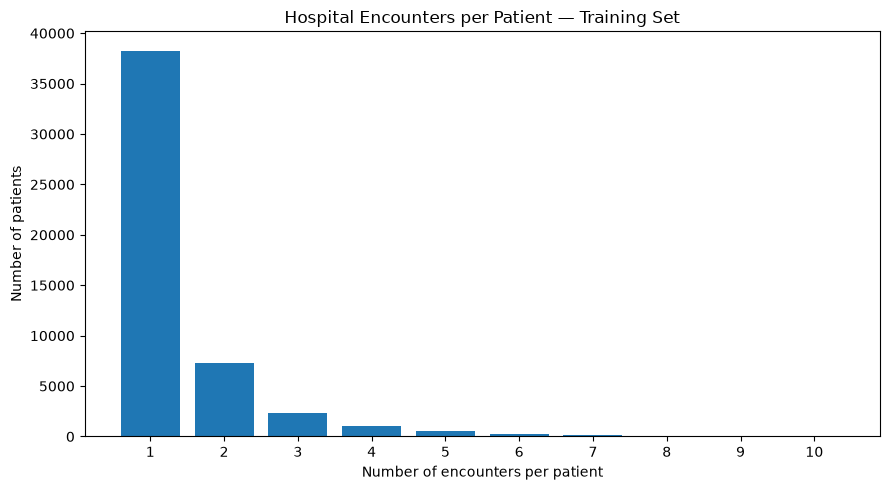

In [7]:
# Visualize encounter frequency per patient

plot_frequency = encounter_frequency[
    encounter_frequency["encounters_per_patient"] <= 10
].copy()

fig, ax = plt.subplots(figsize=(9, 5))

ax.bar(
    plot_frequency["encounters_per_patient"].astype(str),
    plot_frequency["patients"],
)

ax.set_title("Hospital Encounters per Patient — Training Set")
ax.set_xlabel("Number of encounters per patient")
ax.set_ylabel("Number of patients")

plt.tight_layout()
plt.show()

In [8]:
# Compare readmission prevalence by patient utilization history

patient_utilization = patient_encounter_counts.rename(
    "patient_encounter_count"
).to_frame()

patient_utilization["utilization_group"] = np.where(
    patient_utilization["patient_encounter_count"] == 1,
    "Single encounter",
    "Multiple encounters",
)

utilization_analysis = (
    df_train[[PATIENT_ID, TARGET]]
    .merge(
        patient_utilization,
        left_on=PATIENT_ID,
        right_index=True,
        how="left",
        validate="many_to_one",
    )
    .groupby("utilization_group", observed=True)
    .agg(
        encounters=(TARGET, "size"),
        patients=(PATIENT_ID, "nunique"),
        readmissions=(TARGET, "sum"),
        readmission_rate=(TARGET, "mean"),
    )
    .reset_index()
)

utilization_analysis["readmission_pct"] = utilization_analysis["readmission_rate"] * 100

utilization_analysis

,utilization_group,encounters,patients,readmissions,readmission_rate,readmission_pct
0,Multiple encounters,33247,11789,6512,0.1959,19.5867
1,Single encounter,38273,38273,1509,0.0394,3.9427


In [9]:
# Display utilization comparison in a compact, readable format

utilization_display = utilization_analysis[
    [
        "utilization_group",
        "patients",
        "encounters",
        "readmissions",
        "readmission_pct",
    ]
].copy()

utilization_display["readmission_pct"] = utilization_display["readmission_pct"].round(2)

print("Readmission by patient utilization group")
print("-" * 60)

for _, row in utilization_display.iterrows():
    print(
        f"{row['utilization_group']:<20} "
        f"patients={int(row['patients']):>6,} | "
        f"encounters={int(row['encounters']):>6,} | "
        f"readmissions={int(row['readmissions']):>5,} | "
        f"rate={row['readmission_pct']:.2f}%"
    )

utilization_display

Readmission by patient utilization group
------------------------------------------------------------
Multiple encounters  patients=11,789 | encounters=33,247 | readmissions=6,512 | rate=19.59%
Single encounter     patients=38,273 | encounters=38,273 | readmissions=1,509 | rate=3.94%


,utilization_group,patients,encounters,readmissions,readmission_pct
0,Multiple encounters,11789,33247,6512,19.5900
1,Single encounter,38273,38273,1509,3.9400


### 3C Interpretation

Hospital utilization is highly concentrated among a subset of patients. Of the **50,062 unique patients** in the training partition, **11,789 (23.5%)** have multiple recorded encounters, yet these patients account for **33,247 of 71,520 encounters (46.5%)**.

A pronounced descriptive relationship is also observed between repeated utilization and 30-day readmission. Encounters belonging to patients with multiple observed hospital encounters have a **19.59% readmission rate**, compared with **3.94%** among patients represented by a single encounter — approximately a **fivefold difference in prevalence**.

This pattern suggests that repeated healthcare utilization identifies a clinically important higher-risk population. However, the result is **descriptive rather than causal**, and total observed encounter frequency should not automatically be treated as a deployable predictor because it may incorporate information accumulated outside the prediction time point.

The finding therefore motivates further investigation of utilization-related variables that are available at the time of an encounter while preserving temporal validity and avoiding information leakage.

## 3D — Demographic Patterns and Readmission

This section examines how 30-day readmission prevalence varies across major demographic characteristics in the training population:

- age group,
- gender,
- race.

For each characteristic, both **population representation** and **readmission prevalence** are considered. This distinction is important because groups with large numbers of readmissions may simply represent a larger share of the underlying patient population.

These analyses are descriptive and do not imply that demographic characteristics independently cause differences in readmission risk.

In [10]:
# 3D.1 Examine age-group distribution and 30-day readmission prevalence

age_analysis = (
    df_train.groupby("age", observed=True)
    .agg(
        encounters=(TARGET, "size"),
        readmissions=(TARGET, "sum"),
        readmission_rate=(TARGET, "mean"),
    )
    .reset_index()
)

age_analysis["population_pct"] = age_analysis["encounters"] / len(df_train) * 100

age_analysis["readmission_pct"] = age_analysis["readmission_rate"] * 100

# Preserve the natural ordinal structure of the age bands
age_order = [
    "[0-10)",
    "[10-20)",
    "[20-30)",
    "[30-40)",
    "[40-50)",
    "[50-60)",
    "[60-70)",
    "[70-80)",
    "[80-90)",
    "[90-100)",
]

age_analysis["age"] = pd.Categorical(
    age_analysis["age"],
    categories=age_order,
    ordered=True,
)

age_analysis = age_analysis.sort_values("age").reset_index(drop=True)

assert age_analysis["encounters"].sum() == len(df_train)
assert age_analysis["readmissions"].sum() == df_train[TARGET].sum()

age_analysis[
    [
        "age",
        "encounters",
        "population_pct",
        "readmissions",
        "readmission_pct",
    ]
]

,age,encounters,population_pct,readmissions,readmission_pct
0,[0-10),107,0.1496,1,0.9346
1,[10-20),486,0.6795,33,6.7901
2,[20-30),1223,1.7100,194,15.8626
3,[30-40),2613,3.6535,286,10.9453
4,[40-50),6853,9.5819,726,10.5939
5,[50-60),11980,16.7506,1095,9.1402
6,[60-70),15699,21.9505,1780,11.3383
7,[70-80),18370,25.6851,2189,11.9162
8,[80-90),12191,17.0456,1481,12.1483
9,[90-100),1998,2.7936,236,11.8118


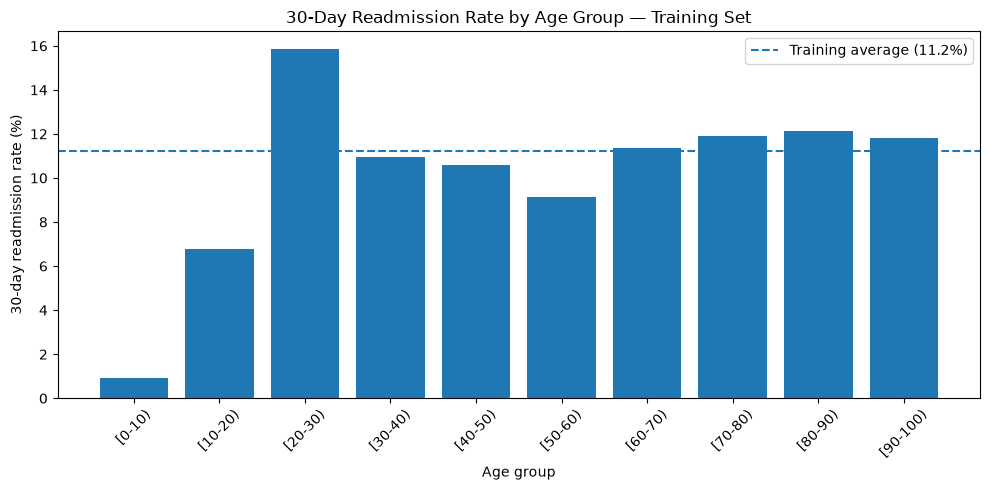

In [11]:
# Visualize 30-day readmission prevalence across age groups

fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.bar(
    age_analysis["age"].astype(str),
    age_analysis["readmission_pct"],
)

ax.axhline(
    positive_rate * 100,
    linestyle="--",
    linewidth=1.5,
    label=f"Training average ({positive_rate:.1%})",
)

ax.set_title("30-Day Readmission Rate by Age Group — Training Set")
ax.set_xlabel("Age group")
ax.set_ylabel("30-day readmission rate (%)")

ax.tick_params(axis="x", rotation=45)
ax.legend()

plt.tight_layout()
plt.show()

### Age-group interpretation

The training population is concentrated among older adults. Patients aged **60–89 account for the majority of encounters**, with the `[70-80)` age group representing the largest individual segment.

Thirty-day readmission prevalence varies across age groups, although the relationship is not strictly monotonic. Several older age groups exhibit readmission rates near or above the overall training prevalence of **11.22%**.

The `[20-30)` group shows a comparatively high observed readmission rate, but this group represents only a small fraction of the training population. Similarly, the youngest age groups contain relatively few encounters. Rates for these smaller groups should therefore be interpreted cautiously because they are more susceptible to sampling variability.

Overall, age appears potentially informative for readmission modeling, but the observed differences should be evaluated alongside other clinical and utilization characteristics rather than interpreted as an independent causal effect.

In [12]:
# 3D.2 Examine gender distribution and 30-day readmission prevalence

gender_analysis = (
    df_train.groupby("gender", observed=True)
    .agg(
        encounters=(TARGET, "size"),
        readmissions=(TARGET, "sum"),
        readmission_rate=(TARGET, "mean"),
    )
    .reset_index()
)

gender_analysis["population_pct"] = gender_analysis["encounters"] / len(df_train) * 100

gender_analysis["readmission_pct"] = gender_analysis["readmission_rate"] * 100

gender_analysis = gender_analysis.sort_values(
    "encounters", ascending=False
).reset_index(drop=True)

assert gender_analysis["encounters"].sum() == len(df_train)
assert gender_analysis["readmissions"].sum() == df_train[TARGET].sum()

gender_analysis[
    [
        "gender",
        "encounters",
        "population_pct",
        "readmissions",
        "readmission_pct",
    ]
]

,gender,encounters,population_pct,readmissions,readmission_pct
0,Female,38339,53.6060,4319,11.2653
1,Male,33180,46.3926,3702,11.1573
2,Unknown/Invalid,1,0.0014,0,0.0000


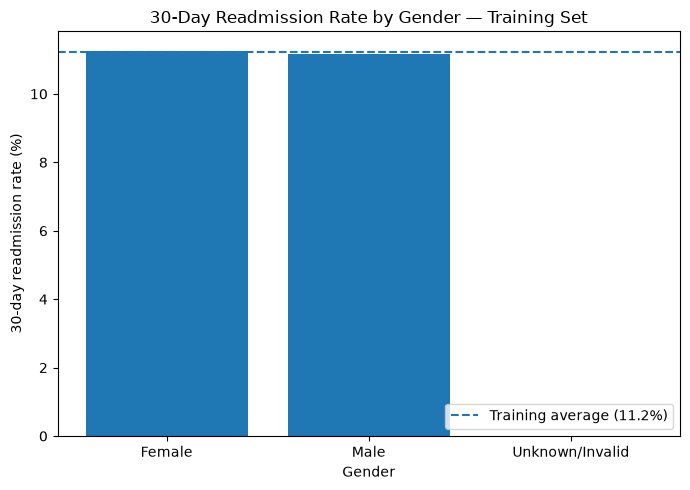

In [13]:
# Visualize 30-day readmission prevalence by gender

fig, ax = plt.subplots(figsize=(7, 5))

bars = ax.bar(
    gender_analysis["gender"].astype(str),
    gender_analysis["readmission_pct"],
)

ax.axhline(
    positive_rate * 100,
    linestyle="--",
    linewidth=1.5,
    label=f"Training average ({positive_rate:.1%})",
)

ax.set_title("30-Day Readmission Rate by Gender — Training Set")
ax.set_xlabel("Gender")
ax.set_ylabel("30-day readmission rate (%)")

ax.legend()

plt.tight_layout()
plt.show()

### Gender interpretation

Thirty-day readmission prevalence is nearly identical between female and male encounters, with both groups closely tracking the overall training-set prevalence of approximately **11.2%**.

This suggests that **gender alone provides limited univariate separation** for identifying encounters associated with 30-day readmission in this dataset.

The `Unknown/Invalid` category contains insufficient representation for meaningful interpretation. Gender may still contribute information through interactions with clinical, utilization, or demographic characteristics, so it will be retained for downstream multivariable modeling rather than excluded solely on the basis of this univariate result.

In [14]:
# 3D.3 Examine race distribution and 30-day readmission prevalence

race_analysis = (
    df_train.groupby("race", observed=True)
    .agg(
        encounters=(TARGET, "size"),
        readmissions=(TARGET, "sum"),
        readmission_rate=(TARGET, "mean"),
    )
    .reset_index()
)

race_analysis["population_pct"] = race_analysis["encounters"] / len(df_train) * 100

race_analysis["readmission_pct"] = race_analysis["readmission_rate"] * 100

race_analysis = race_analysis.sort_values("encounters", ascending=False).reset_index(
    drop=True
)

assert race_analysis["encounters"].sum() == len(df_train)
assert race_analysis["readmissions"].sum() == df_train[TARGET].sum()

race_analysis[
    [
        "race",
        "encounters",
        "population_pct",
        "readmissions",
        "readmission_pct",
    ]
]

,race,encounters,population_pct,readmissions,readmission_pct
0,Caucasian,53458,74.7455,6080,11.3734
1,AfricanAmerican,13509,18.8884,1499,11.0963
2,Unknown,1621,2.2665,150,9.2535
3,Hispanic,1423,1.9897,158,11.1033
4,Other,1063,1.4863,101,9.5014
5,Asian,446,0.6236,33,7.3991


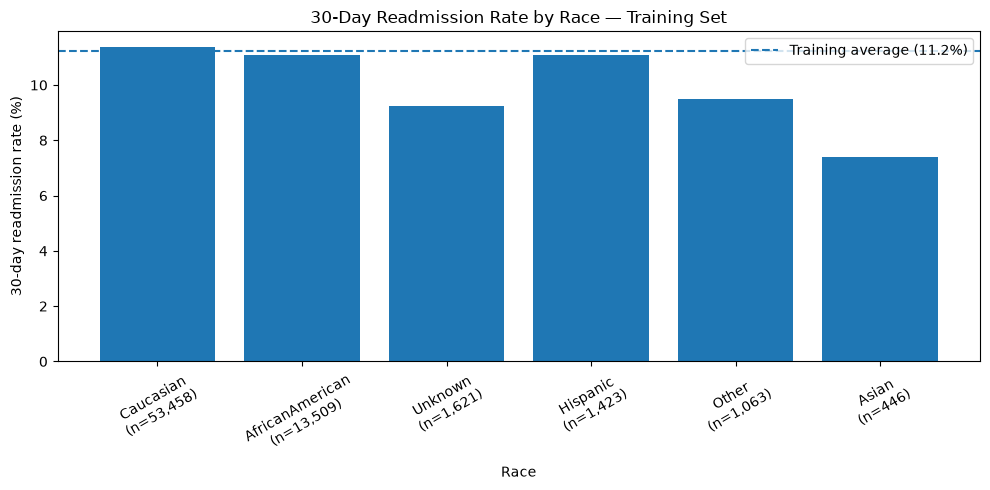

In [15]:
# 3D.3 Visualize 30-day readmission prevalence by race

race_plot = race_analysis.copy()

race_plot["label"] = (
    race_plot["race"].astype(str)
    + "\n(n="
    + race_plot["encounters"].map(lambda x: f"{x:,}")
    + ")"
)

fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.bar(
    race_plot["label"],
    race_plot["readmission_pct"],
)

ax.axhline(
    positive_rate * 100,
    linestyle="--",
    linewidth=1.5,
    label=f"Training average ({positive_rate:.1%})",
)

ax.set_title("30-Day Readmission Rate by Race — Training Set")
ax.set_xlabel("Race")
ax.set_ylabel("30-day readmission rate (%)")

ax.tick_params(axis="x", rotation=30)
ax.legend()

plt.tight_layout()
plt.show()

### Race interpretation

The training population is demographically imbalanced with respect to the recorded race variable. Approximately **74.8%** of encounters are categorized as Caucasian and **18.9%** as African American, while each remaining category represents less than 3% of training encounters.

Observed 30-day readmission prevalence is relatively similar among the three larger interpretable groups: approximately **11.4% for Caucasian**, **11.1% for African American**, and **11.1% for Hispanic encounters**, compared with an overall training prevalence of approximately **11.2%**.

Some smaller categories exhibit lower observed readmission rates, including the Asian category; however, these estimates are based on substantially smaller samples and should therefore be interpreted cautiously.

These results describe associations within this dataset and should not be interpreted as evidence that race itself causes differences in readmission risk. Recorded race may also reflect or correlate with socioeconomic, healthcare-access, geographic, clinical, and data-collection factors not independently represented by this univariate analysis.

## 3D.4 — Age × Gender Interaction

Age and gender individually provide different levels of univariate separation. This section examines whether age-related differences in 30-day readmission prevalence vary across gender groups.

Because some age groups contain relatively few encounters, subgroup rates are interpreted alongside their sample sizes and are treated as descriptive associations rather than causal effects.

In [16]:
# Examine 30-day readmission prevalence across age × gender groups

age_gender_analysis = (
    df_train.groupby(["age", "gender"], observed=True)
    .agg(
        encounters=(TARGET, "size"),
        readmissions=(TARGET, "sum"),
        readmission_rate=(TARGET, "mean"),
    )
    .reset_index()
)

age_gender_analysis["readmission_pct"] = age_gender_analysis["readmission_rate"] * 100

# Preserve the natural age-band ordering
age_order = [
    "[0-10)",
    "[10-20)",
    "[20-30)",
    "[30-40)",
    "[40-50)",
    "[50-60)",
    "[60-70)",
    "[70-80)",
    "[80-90)",
    "[90-100)",
]

age_gender_analysis["age"] = pd.Categorical(
    age_gender_analysis["age"],
    categories=age_order,
    ordered=True,
)

age_gender_analysis = age_gender_analysis.sort_values(["age", "gender"]).reset_index(
    drop=True
)

assert age_gender_analysis["encounters"].sum() == len(df_train)
assert age_gender_analysis["readmissions"].sum() == df_train[TARGET].sum()

age_gender_analysis[
    [
        "age",
        "gender",
        "encounters",
        "readmissions",
        "readmission_pct",
    ]
]

,age,gender,encounters,readmissions,readmission_pct
0,[0-10),Female,61,1,1.6393
1,[0-10),Male,46,0,0.0000
2,[10-20),Female,292,21,7.1918
3,[10-20),Male,194,12,6.1856
4,[20-30),Female,812,148,18.2266
5,[20-30),Male,411,46,11.1922
6,[30-40),Female,1545,185,11.9741
7,[30-40),Male,1068,101,9.4569
8,[40-50),Female,3364,346,10.2854
9,[40-50),Male,3489,380,10.8914


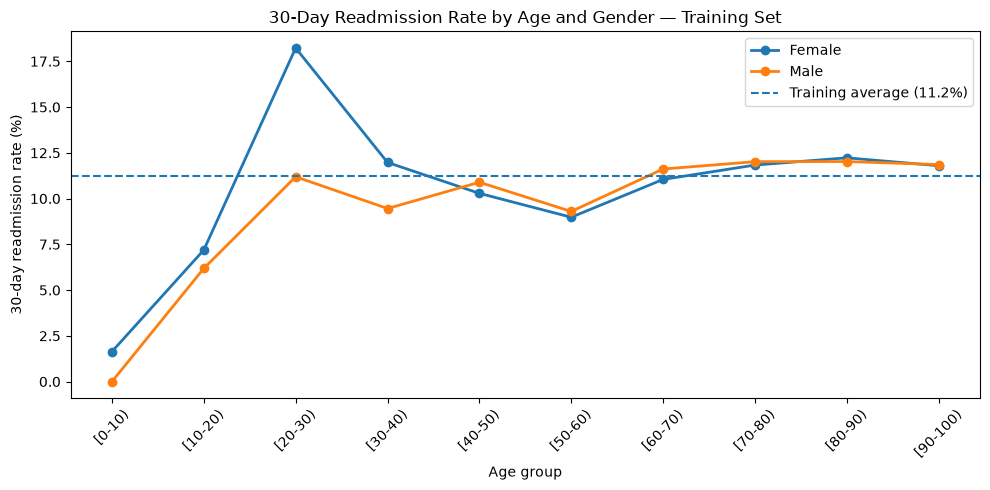

In [17]:
# Visualize age × gender readmission patterns

age_gender_plot = age_gender_analysis[
    age_gender_analysis["gender"].isin(["Female", "Male"])
].copy()

fig, ax = plt.subplots(figsize=(10, 5))

for gender, group in age_gender_plot.groupby("gender", observed=True):
    group = group.sort_values("age")

    ax.plot(
        group["age"].astype(str),
        group["readmission_pct"],
        marker="o",
        linewidth=2,
        label=gender,
    )

ax.axhline(
    positive_rate * 100,
    linestyle="--",
    linewidth=1.5,
    label=f"Training average ({positive_rate:.1%})",
)

ax.set_title("30-Day Readmission Rate by Age and Gender — Training Set")
ax.set_xlabel("Age group")
ax.set_ylabel("30-day readmission rate (%)")

ax.tick_params(axis="x", rotation=45)
ax.legend()

plt.tight_layout()
plt.show()

### Age × gender interpretation

Age-related readmission patterns show some variation between female and male encounters, although the magnitude of the difference is not consistent across age groups.

The largest apparent separation occurs among some younger age groups. For example, within the `[20-30)` category, the observed readmission rate is approximately **18.2% for female encounters** compared with **11.2% for male encounters**. However, these younger subgroups contain substantially fewer observations than the older age groups, making their estimated rates more susceptible to sampling variability.

Across several of the more heavily represented middle-aged and older groups, female and male readmission rates are considerably closer. The descriptive analysis therefore does not indicate a simple or consistently directional age-by-gender relationship.

These results motivate retaining both age and gender for multivariable modeling, where potential interaction effects can be evaluated alongside clinical and healthcare-utilization characteristics. The observed subgroup differences should not be interpreted as causal effects.

## 3D — Demographic Patterns: Key Findings

Demographic characteristics provide useful descriptive context but show substantially less univariate separation than patient utilization history.

- The training population is concentrated among **older adults**, particularly patients aged 60–89.
- Readmission prevalence varies across age groups, but the pattern is **not strictly monotonic**, and estimates for younger groups are based on relatively small samples.
- **Female and male encounters have nearly identical overall readmission prevalence**, suggesting limited univariate separation from gender alone.
- The recorded race distribution is highly imbalanced, while the larger race categories exhibit relatively similar observed readmission prevalence.
- Age-by-gender analysis reveals some subgroup variation, particularly among younger patients, but smaller sample sizes limit the strength of conclusions that can be drawn from these differences.

Overall, the demographic analysis supports retaining these variables for downstream multivariable modeling while avoiding strong conclusions based solely on marginal subgroup differences.

# 3E — Healthcare Utilization & Encounter Characteristics

Healthcare utilization characteristics describe both the intensity of the current hospitalization and the patient's recent interaction with the healthcare system.

This section examines whether utilization-related characteristics are associated with 30-day readmission prevalence. Particular attention is given to:

- length of the current hospital stay,
- prior inpatient utilization,
- prior emergency-department utilization,
- prior outpatient utilization, and
- combinations of prior healthcare utilization.

These analyses are performed using the training partition only. Observed relationships are descriptive associations and are not interpreted as causal effects.

## 3E.1 — Length of Hospital Stay

Length of stay may reflect hospitalization complexity, illness severity, treatment requirements, or other characteristics associated with subsequent readmission.

The analysis below examines both the distribution of `time_in_hospital` and observed 30-day readmission prevalence across hospital-stay durations.

In [18]:
# Summarize time-in-hospital distribution

stay_summary = df_train["time_in_hospital"].describe()

stay_analysis = (
    df_train.groupby("time_in_hospital", observed=True)
    .agg(
        encounters=(TARGET, "size"),
        readmissions=(TARGET, "sum"),
        readmission_rate=(TARGET, "mean"),
    )
    .reset_index()
    .sort_values("time_in_hospital")
    .reset_index(drop=True)
)

stay_analysis["population_pct"] = stay_analysis["encounters"] / len(df_train) * 100

stay_analysis["readmission_pct"] = stay_analysis["readmission_rate"] * 100

assert stay_analysis["encounters"].sum() == len(df_train)
assert stay_analysis["readmissions"].sum() == df_train[TARGET].sum()

print("Time-in-hospital summary")
print("-" * 50)
print(f"Minimum stay:       {int(stay_summary['min'])} day(s)")
print(f"Median stay:        {stay_summary['50%']:.1f} day(s)")
print(f"Mean stay:          {stay_summary['mean']:.2f} day(s)")
print(f"Maximum stay:       {int(stay_summary['max'])} day(s)")
print()

stay_analysis[
    [
        "time_in_hospital",
        "encounters",
        "population_pct",
        "readmissions",
        "readmission_pct",
    ]
]

Time-in-hospital summary
--------------------------------------------------
Minimum stay:       1 day(s)
Median stay:        4.0 day(s)
Mean stay:          4.39 day(s)
Maximum stay:       14 day(s)



,time_in_hospital,encounters,population_pct,readmissions,readmission_pct
0,1,10023,14.0143,834,8.3209
1,2,12090,16.9044,1231,10.1820
2,3,12439,17.3923,1332,10.7083
3,4,9885,13.8213,1147,11.6034
4,5,7001,9.7889,857,12.2411
5,6,5292,7.3993,670,12.6606
6,7,4161,5.8180,527,12.6652
7,8,3026,4.2310,426,14.0780
8,9,2040,2.8523,282,13.8235
9,10,1657,2.3168,237,14.3030


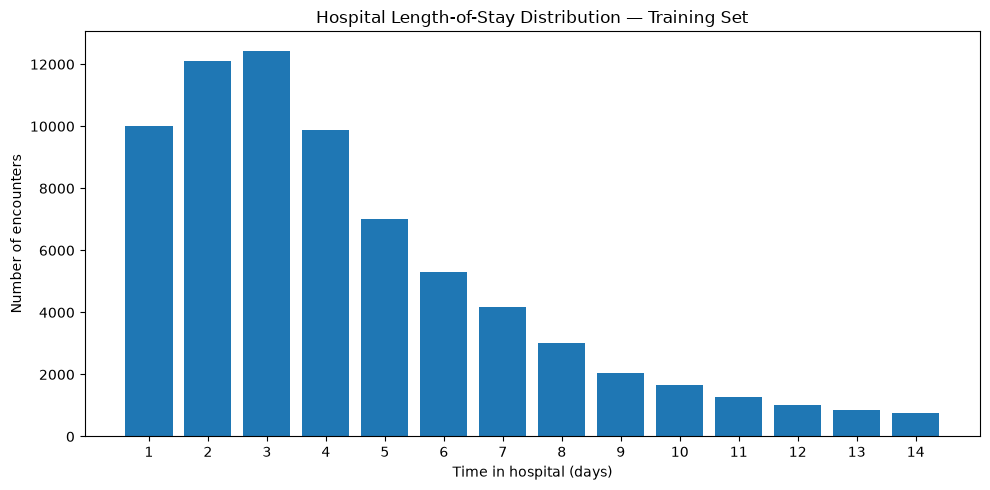

In [19]:
# Visualize hospital length-of-stay distribution

fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(
    stay_analysis["time_in_hospital"],
    stay_analysis["encounters"],
)

ax.set_title("Hospital Length-of-Stay Distribution — Training Set")
ax.set_xlabel("Time in hospital (days)")
ax.set_ylabel("Number of encounters")

ax.set_xticks(stay_analysis["time_in_hospital"])

plt.tight_layout()
plt.show()

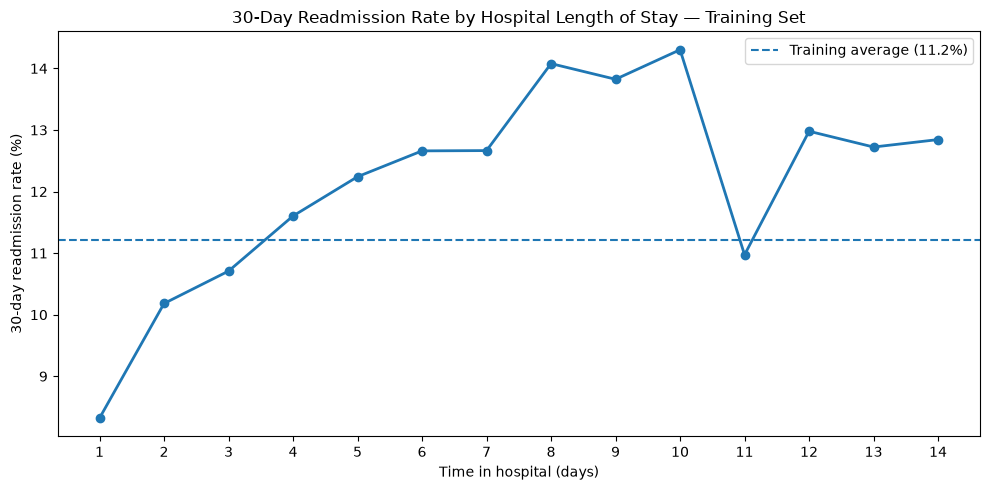

In [20]:
# Visualize 30-day readmission prevalence by hospital stay duration

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    stay_analysis["time_in_hospital"],
    stay_analysis["readmission_pct"],
    marker="o",
    linewidth=2,
)

ax.axhline(
    positive_rate * 100,
    linestyle="--",
    linewidth=1.5,
    label=f"Training average ({positive_rate:.1%})",
)

ax.set_title("30-Day Readmission Rate by Hospital Length of Stay — Training Set")
ax.set_xlabel("Time in hospital (days)")
ax.set_ylabel("30-day readmission rate (%)")

ax.set_xticks(stay_analysis["time_in_hospital"])
ax.legend()

plt.tight_layout()
plt.show()

### Length-of-stay interpretation

Hospital length of stay shows a meaningful descriptive association with 30-day readmission in the training data.

The distribution is concentrated among relatively short hospitalizations: the median stay is **4 days** and the mean is **4.39 days**, while progressively fewer encounters occur at longer durations.

Readmission prevalence generally increases with length of stay. One-day hospitalizations exhibit a readmission rate of approximately **8%**, below the overall training prevalence of approximately **11.2%**. Rates increase across longer stays and reach approximately **14%** among several of the longer-duration groups.

The pattern is not perfectly monotonic, particularly among the longest stays where encounter counts are smaller, but the overall relationship suggests that longer hospitalizations may contain useful information for predicting subsequent 30-day readmission.

Length of stay should therefore be retained as a candidate predictor for downstream modeling. This association should not be interpreted causally: longer hospitalization may reflect underlying illness severity, treatment complexity, complications, comorbidity burden, or other clinical characteristics associated with readmission risk.

## 3E.2 — Prior Inpatient Utilization

Prior inpatient utilization provides a measure of recent hospitalization history and may identify patients with recurrent or complex healthcare needs.

This analysis examines the distribution of inpatient visits during the preceding year and evaluates how 30-day readmission prevalence varies with increasing prior inpatient utilization.

In [21]:
# Analyze prior inpatient utilization

inpatient_analysis = (
    df_train.groupby("number_inpatient", observed=True)
    .agg(
        encounters=(TARGET, "size"),
        readmissions=(TARGET, "sum"),
        readmission_rate=(TARGET, "mean"),
    )
    .reset_index()
    .sort_values("number_inpatient")
    .reset_index(drop=True)
)

inpatient_analysis["population_pct"] = (
    inpatient_analysis["encounters"] / len(df_train) * 100
)

inpatient_analysis["readmission_pct"] = inpatient_analysis["readmission_rate"] * 100

assert inpatient_analysis["encounters"].sum() == len(df_train)
assert inpatient_analysis["readmissions"].sum() == df_train[TARGET].sum()

print("Prior inpatient utilization")
print("-" * 60)

print(
    f"Patients/encounters with no prior inpatient visits: "
    f"{(df_train['number_inpatient'] == 0).mean():.1%}"
)

print(
    f"Patients/encounters with >=1 prior inpatient visit: "
    f"{(df_train['number_inpatient'] >= 1).mean():.1%}"
)

print(f"Maximum prior inpatient visits: " f"{df_train['number_inpatient'].max()}")

inpatient_analysis[
    [
        "number_inpatient",
        "encounters",
        "population_pct",
        "readmissions",
        "readmission_pct",
    ]
]

Prior inpatient utilization
------------------------------------------------------------
Patients/encounters with no prior inpatient visits: 66.2%
Patients/encounters with >=1 prior inpatient visit: 33.8%
Maximum prior inpatient visits: 21


,number_inpatient,encounters,population_pct,readmissions,readmission_pct
0,0,47360,66.2192,3990,8.4248
1,1,13720,19.1834,1775,12.9373
2,2,5394,7.5419,961,17.8161
3,3,2448,3.4228,503,20.5474
4,4,1133,1.5842,263,23.2127
5,5,562,0.7858,165,29.3594
6,6,344,0.4810,125,36.3372
7,7,207,0.2894,70,33.8164
8,8,111,0.1552,54,48.6486
9,9,87,0.1216,36,41.3793


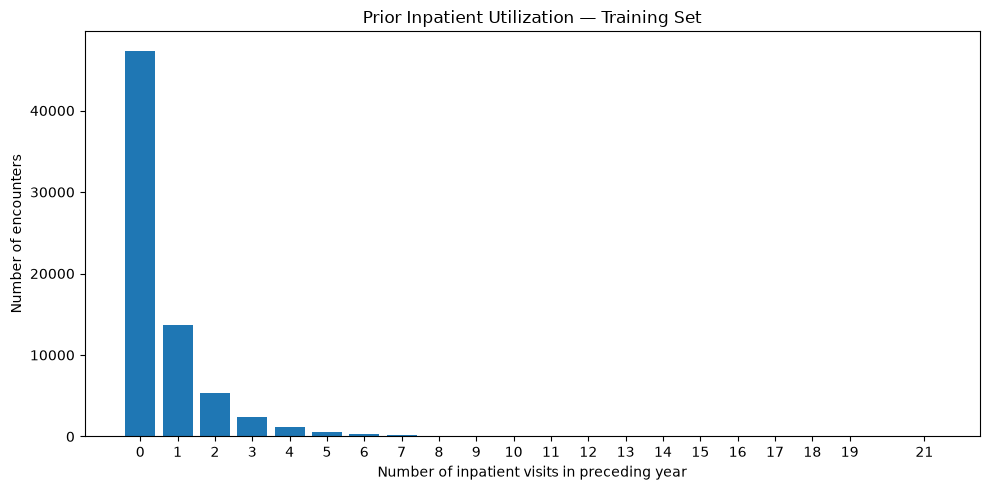

In [22]:
# Visualize prior inpatient utilization distribution

fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(
    inpatient_analysis["number_inpatient"],
    inpatient_analysis["encounters"],
)

ax.set_title("Prior Inpatient Utilization — Training Set")
ax.set_xlabel("Number of inpatient visits in preceding year")
ax.set_ylabel("Number of encounters")

ax.set_xticks(inpatient_analysis["number_inpatient"])

plt.tight_layout()
plt.show()

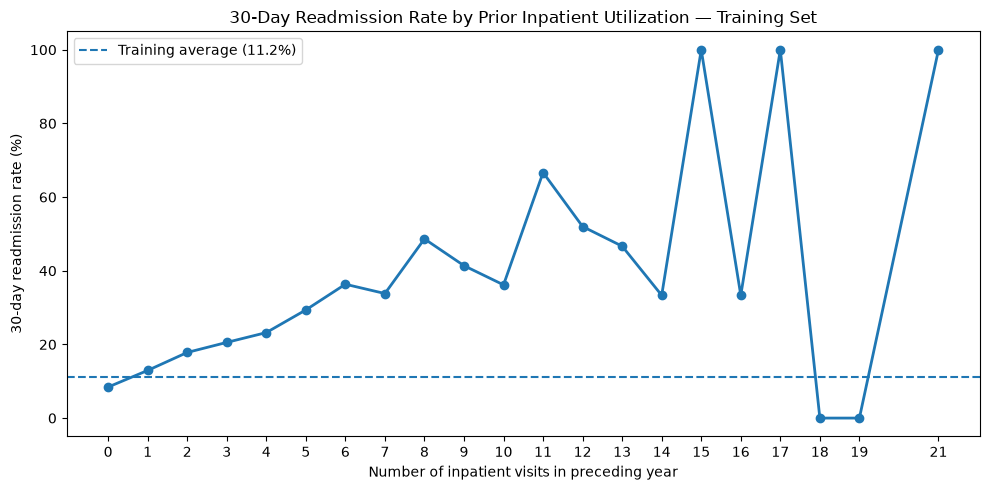

In [23]:
# Visualize readmission prevalence by prior inpatient utilization

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    inpatient_analysis["number_inpatient"],
    inpatient_analysis["readmission_pct"],
    marker="o",
    linewidth=2,
)

ax.axhline(
    positive_rate * 100,
    linestyle="--",
    linewidth=1.5,
    label=f"Training average ({positive_rate:.1%})",
)

ax.set_title("30-Day Readmission Rate by Prior Inpatient Utilization — Training Set")
ax.set_xlabel("Number of inpatient visits in preceding year")
ax.set_ylabel("30-day readmission rate (%)")

ax.set_xticks(inpatient_analysis["number_inpatient"])
ax.legend()

plt.tight_layout()
plt.show()

In [24]:
# 3E.2A Group prior inpatient utilization for stable interpretation

inpatient_grouped = df_train.copy()

inpatient_grouped["prior_inpatient_group"] = pd.cut(
    inpatient_grouped["number_inpatient"],
    bins=[-1, 0, 1, 2, np.inf],
    labels=["0", "1", "2", "3+"],
)

inpatient_group_analysis = (
    inpatient_grouped.groupby("prior_inpatient_group", observed=True)
    .agg(
        encounters=(TARGET, "size"),
        readmissions=(TARGET, "sum"),
        readmission_rate=(TARGET, "mean"),
    )
    .reset_index()
)

inpatient_group_analysis["population_pct"] = (
    inpatient_group_analysis["encounters"] / len(df_train) * 100
)

inpatient_group_analysis["readmission_pct"] = (
    inpatient_group_analysis["readmission_rate"] * 100
)

assert inpatient_group_analysis["encounters"].sum() == len(df_train)
assert inpatient_group_analysis["readmissions"].sum() == df_train[TARGET].sum()

inpatient_group_analysis[
    [
        "prior_inpatient_group",
        "encounters",
        "population_pct",
        "readmissions",
        "readmission_pct",
    ]
]

,prior_inpatient_group,encounters,population_pct,readmissions,readmission_pct
0,0,47360,66.2192,3990,8.4248
1,1,13720,19.1834,1775,12.9373
2,2,5394,7.5419,961,17.8161
3,3+,5046,7.0554,1295,25.6639


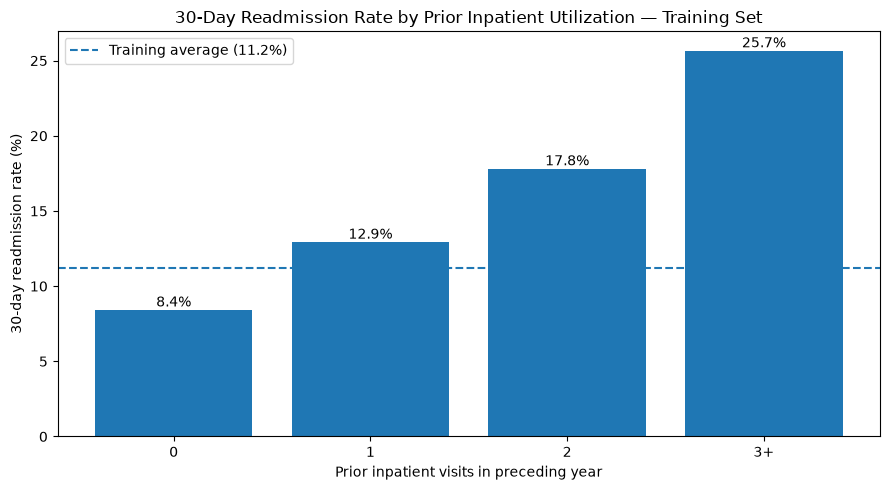

In [25]:
# Visualize grouped prior inpatient utilization

fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.bar(
    inpatient_group_analysis["prior_inpatient_group"].astype(str),
    inpatient_group_analysis["readmission_pct"],
)

ax.axhline(
    positive_rate * 100,
    linestyle="--",
    linewidth=1.5,
    label=f"Training average ({positive_rate:.1%})",
)

for bar, rate in zip(
    bars,
    inpatient_group_analysis["readmission_pct"],
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{rate:.1f}%",
        ha="center",
        va="bottom",
    )

ax.set_title("30-Day Readmission Rate by Prior Inpatient Utilization — Training Set")
ax.set_xlabel("Prior inpatient visits in preceding year")
ax.set_ylabel("30-day readmission rate (%)")
ax.legend()

plt.tight_layout()
plt.show()

### 3E.2 Prior inpatient utilization interpretation

Prior inpatient utilization exhibits a strong and consistent association with 30-day readmission in the training data.

Encounters with **no inpatient visits during the preceding year** have an observed 30-day readmission rate of approximately **8.4%**, below the overall training prevalence of approximately **11.2%**. Readmission prevalence increases progressively with prior inpatient utilization:

- **0 prior inpatient visits:** 8.4%
- **1 prior inpatient visit:** 12.9%
- **2 prior inpatient visits:** 17.8%
- **3 or more prior inpatient visits:** 25.7%

The grouped analysis reveals a clear utilization-risk gradient. Encounters associated with three or more prior inpatient visits have an observed readmission prevalence approximately three times that of encounters with no prior inpatient utilization.

The ungrouped analysis becomes unstable at very high utilization counts because these values contain relatively few observations. Grouping the upper tail therefore provides a more statistically stable descriptive representation while preserving the underlying pattern. The original `number_inpatient` variable will remain available in its numeric form for downstream modeling.

These findings suggest that recent inpatient utilization may be an important predictive feature for 30-day readmission. The relationship should not be interpreted causally, as repeated hospitalization may reflect underlying disease burden, clinical complexity, healthcare-access patterns, or other factors associated with readmission risk.

## 3E.3 — Prior Emergency Utilization

Emergency-department utilization during the preceding year may provide additional information about recent healthcare needs, disease instability, and patterns of acute-care use.

This analysis evaluates the distribution of prior emergency visits and examines whether increasing emergency utilization is associated with higher observed 30-day readmission prevalence.

In [26]:
# Analyze prior emergency utilization

emergency_analysis = (
    df_train.groupby("number_emergency", observed=True)
    .agg(
        encounters=(TARGET, "size"),
        readmissions=(TARGET, "sum"),
        readmission_rate=(TARGET, "mean"),
    )
    .reset_index()
    .sort_values("number_emergency")
    .reset_index(drop=True)
)

emergency_analysis["population_pct"] = (
    emergency_analysis["encounters"] / len(df_train) * 100
)

emergency_analysis["readmission_pct"] = emergency_analysis["readmission_rate"] * 100

assert emergency_analysis["encounters"].sum() == len(df_train)
assert emergency_analysis["readmissions"].sum() == df_train[TARGET].sum()

print("Prior emergency utilization")
print("-" * 60)

print(
    f"No prior emergency visits: " f"{(df_train['number_emergency'] == 0).mean():.1%}"
)

print(
    f"At least one prior emergency visit: "
    f"{(df_train['number_emergency'] >= 1).mean():.1%}"
)

print(f"Maximum prior emergency visits: " f"{df_train['number_emergency'].max()}")

emergency_analysis[
    [
        "number_emergency",
        "encounters",
        "population_pct",
        "readmissions",
        "readmission_pct",
    ]
]

Prior emergency utilization
------------------------------------------------------------
No prior emergency visits: 88.8%
At least one prior emergency visit: 11.2%
Maximum prior emergency visits: 76


,number_emergency,encounters,population_pct,readmissions,readmission_pct
0,0,63478,88.7556,6667,10.5029
1,1,5428,7.5895,757,13.9462
2,2,1400,1.9575,277,19.7857
3,3,528,0.7383,121,22.9167
4,4,273,0.3817,82,30.0366
5,5,137,0.1916,36,26.2774
6,6,70,0.0979,18,25.7143
7,7,61,0.0853,17,27.8689
8,8,40,0.0559,12,30.0000
9,9,26,0.0364,9,34.6154


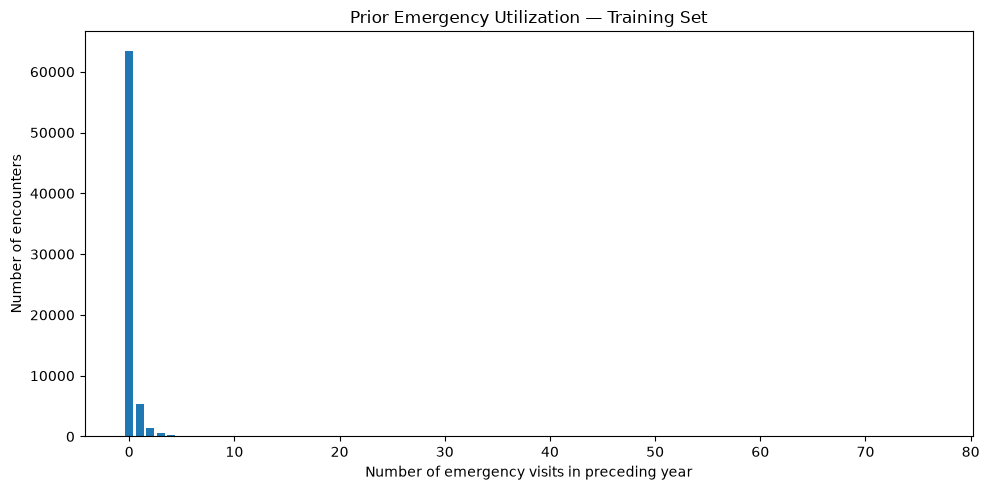

In [27]:
# Visualize prior emergency utilization distribution

fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(
    emergency_analysis["number_emergency"],
    emergency_analysis["encounters"],
)

ax.set_title("Prior Emergency Utilization — Training Set")
ax.set_xlabel("Number of emergency visits in preceding year")
ax.set_ylabel("Number of encounters")

plt.tight_layout()
plt.show()

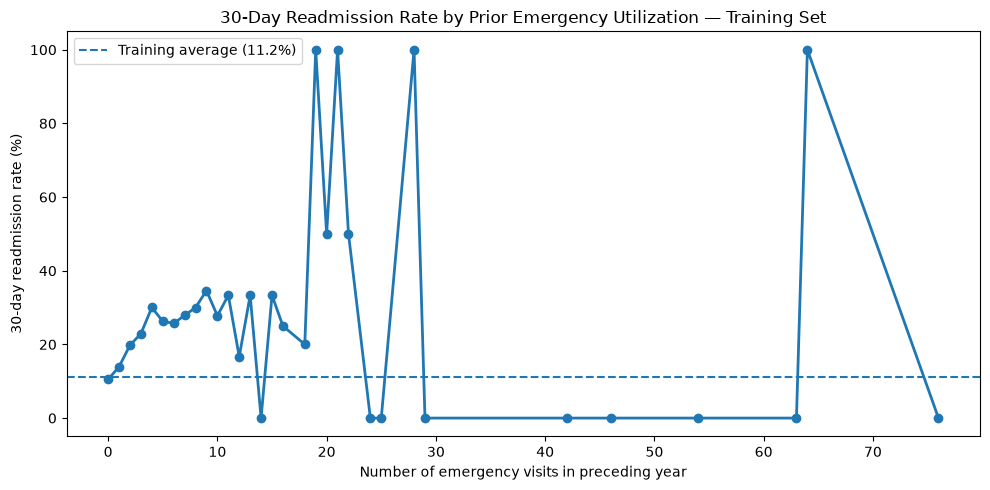

In [28]:
# Visualize readmission prevalence by prior emergency utilization

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    emergency_analysis["number_emergency"],
    emergency_analysis["readmission_pct"],
    marker="o",
    linewidth=2,
)

ax.axhline(
    positive_rate * 100,
    linestyle="--",
    linewidth=1.5,
    label=f"Training average ({positive_rate:.1%})",
)

ax.set_title("30-Day Readmission Rate by Prior Emergency Utilization — Training Set")
ax.set_xlabel("Number of emergency visits in preceding year")
ax.set_ylabel("30-day readmission rate (%)")

ax.legend()

plt.tight_layout()
plt.show()

In [29]:
# 3E.3A Group prior emergency utilization for stable interpretation

emergency_grouped = df_train.copy()

emergency_grouped["prior_emergency_group"] = pd.cut(
    emergency_grouped["number_emergency"],
    bins=[-1, 0, 1, 3, np.inf],
    labels=["0", "1", "2–3", "4+"],
)

emergency_group_analysis = (
    emergency_grouped.groupby("prior_emergency_group", observed=True)
    .agg(
        encounters=(TARGET, "size"),
        readmissions=(TARGET, "sum"),
        readmission_rate=(TARGET, "mean"),
    )
    .reset_index()
)

emergency_group_analysis["population_pct"] = (
    emergency_group_analysis["encounters"] / len(df_train) * 100
)

emergency_group_analysis["readmission_pct"] = (
    emergency_group_analysis["readmission_rate"] * 100
)

assert emergency_group_analysis["encounters"].sum() == len(df_train)
assert emergency_group_analysis["readmissions"].sum() == df_train[TARGET].sum()

emergency_group_analysis[
    [
        "prior_emergency_group",
        "encounters",
        "population_pct",
        "readmissions",
        "readmission_pct",
    ]
]

,prior_emergency_group,encounters,population_pct,readmissions,readmission_pct
0,0,63478,88.7556,6667,10.5029
1,1,5428,7.5895,757,13.9462
2,2–3,1928,2.6957,398,20.6432
3,4+,686,0.9592,199,29.0087


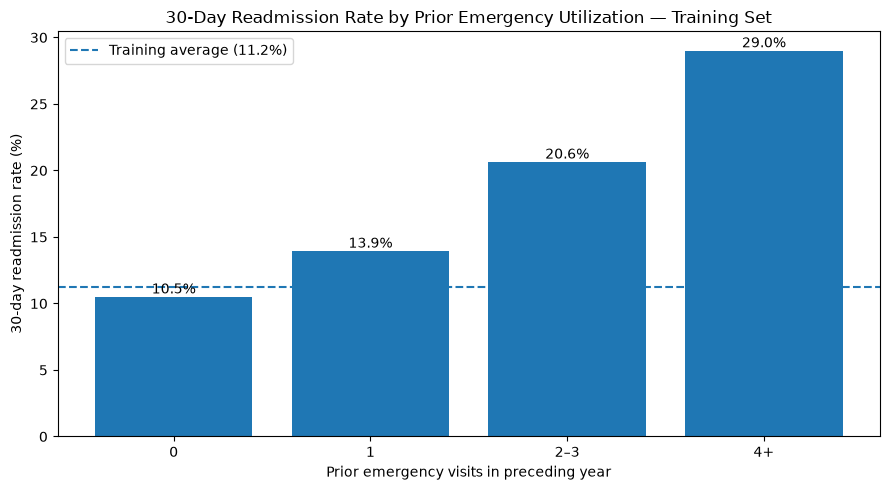

In [30]:
# Visualize grouped prior emergency utilization

fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.bar(
    emergency_group_analysis["prior_emergency_group"].astype(str),
    emergency_group_analysis["readmission_pct"],
)

ax.axhline(
    positive_rate * 100,
    linestyle="--",
    linewidth=1.5,
    label=f"Training average ({positive_rate:.1%})",
)

for bar, rate in zip(
    bars,
    emergency_group_analysis["readmission_pct"],
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{rate:.1f}%",
        ha="center",
        va="bottom",
    )

ax.set_title("30-Day Readmission Rate by Prior Emergency Utilization — Training Set")
ax.set_xlabel("Prior emergency visits in preceding year")
ax.set_ylabel("30-day readmission rate (%)")
ax.legend()

plt.tight_layout()
plt.show()

In [31]:
print("Grouped prior emergency utilization")
print("-" * 65)

for _, row in emergency_group_analysis.iterrows():
    print(
        f"{str(row['prior_emergency_group']):>4} visits | "
        f"encounters={int(row['encounters']):>6,} | "
        f"readmissions={int(row['readmissions']):>5,} | "
        f"rate={row['readmission_pct']:>5.1f}%"
    )

Grouped prior emergency utilization
-----------------------------------------------------------------
   0 visits | encounters=63,478 | readmissions=6,667 | rate= 10.5%
   1 visits | encounters= 5,428 | readmissions=  757 | rate= 13.9%
 2–3 visits | encounters= 1,928 | readmissions=  398 | rate= 20.6%
  4+ visits | encounters=   686 | readmissions=  199 | rate= 29.0%


### 3E.3 Prior emergency utilization interpretation

Prior emergency-department utilization exhibits a strong positive association with 30-day readmission in the training data.

Encounters with **no emergency visits during the preceding year** have an observed readmission rate of approximately **10.5%**, slightly below the overall training prevalence of approximately **11.2%**. Readmission prevalence increases progressively with prior emergency utilization:

- **0 prior emergency visits:** 10.5%
- **1 prior emergency visit:** 13.9%
- **2–3 prior emergency visits:** 20.6%
- **4 or more prior emergency visits:** 29.0%

The grouped results reveal a clear utilization-risk gradient. Encounters in the highest emergency-utilization group exhibit approximately **2.8 times** the observed readmission prevalence of encounters with no prior emergency utilization.

The original ungrouped variable contains a long and extremely sparse upper tail, producing unstable readmission estimates at unusually high utilization counts. Grouping the tail therefore provides a more reliable descriptive summary without altering the original numeric `number_emergency` feature retained for downstream modeling.

Together with the prior inpatient analysis, these findings indicate that recent acute-care utilization may contain substantially more information about subsequent readmission risk than the demographic characteristics examined earlier. These associations should not be interpreted causally, as frequent healthcare utilization may reflect underlying disease burden, clinical instability, access patterns, or other unmeasured patient characteristics.

## 3E.4 — Prior Outpatient Utilization

Outpatient utilization during the preceding year provides information about recent ambulatory healthcare use and may reflect chronic disease management, follow-up intensity, and overall healthcare needs.

This analysis examines the distribution of prior outpatient visits and evaluates whether increasing outpatient utilization is associated with differences in observed 30-day readmission prevalence.

In [32]:
# Analyze prior outpatient utilization

outpatient_analysis = (
    df_train.groupby("number_outpatient", observed=True)
    .agg(
        encounters=(TARGET, "size"),
        readmissions=(TARGET, "sum"),
        readmission_rate=(TARGET, "mean"),
    )
    .reset_index()
    .sort_values("number_outpatient")
    .reset_index(drop=True)
)

outpatient_analysis["population_pct"] = (
    outpatient_analysis["encounters"] / len(df_train) * 100
)

outpatient_analysis["readmission_pct"] = outpatient_analysis["readmission_rate"] * 100

assert outpatient_analysis["encounters"].sum() == len(df_train)
assert outpatient_analysis["readmissions"].sum() == df_train[TARGET].sum()

print("Prior outpatient utilization")
print("-" * 60)

print(
    f"No prior outpatient visits: " f"{(df_train['number_outpatient'] == 0).mean():.1%}"
)

print(
    f"At least one prior outpatient visit: "
    f"{(df_train['number_outpatient'] >= 1).mean():.1%}"
)

print(f"Maximum prior outpatient visits: " f"{df_train['number_outpatient'].max()}")

outpatient_analysis[
    [
        "number_outpatient",
        "encounters",
        "population_pct",
        "readmissions",
        "readmission_pct",
    ]
]

Prior outpatient utilization
------------------------------------------------------------
No prior outpatient visits: 83.5%
At least one prior outpatient visit: 16.5%
Maximum prior outpatient visits: 42


,number_outpatient,encounters,population_pct,readmissions,readmission_pct
0,0,59719,83.4997,6379,10.6817
1,1,5986,8.3697,836,13.9659
2,2,2531,3.5389,378,14.9348
3,3,1472,2.0582,184,12.5000
4,4,793,1.1088,122,15.3846
5,5,375,0.5243,47,12.5333
6,6,215,0.3006,23,10.6977
7,7,109,0.1524,18,16.5138
8,8,69,0.0965,2,2.8986
9,9,64,0.0895,11,17.1875


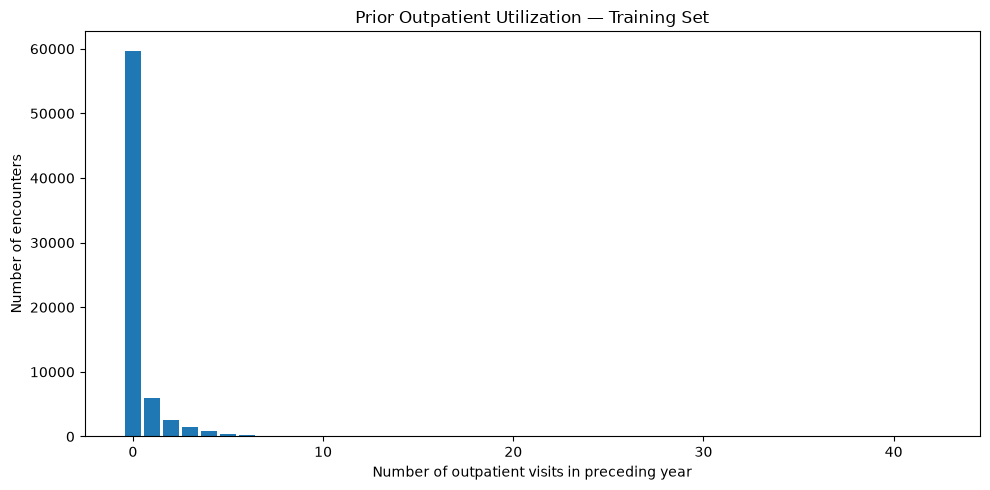

In [33]:
# Visualize prior outpatient utilization distribution

fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(
    outpatient_analysis["number_outpatient"],
    outpatient_analysis["encounters"],
)

ax.set_title("Prior Outpatient Utilization — Training Set")
ax.set_xlabel("Number of outpatient visits in preceding year")
ax.set_ylabel("Number of encounters")

plt.tight_layout()
plt.show()

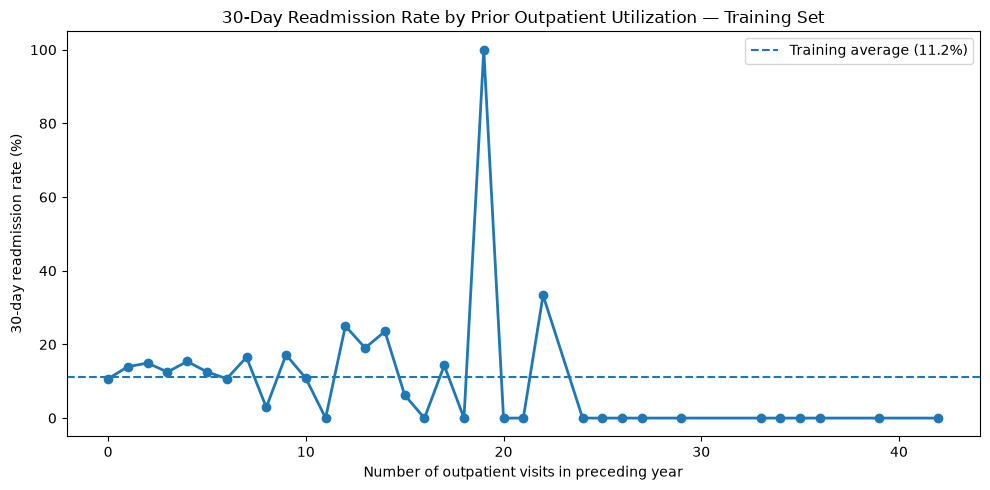

In [34]:
# Visualize readmission prevalence by prior outpatient utilization

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    outpatient_analysis["number_outpatient"],
    outpatient_analysis["readmission_pct"],
    marker="o",
    linewidth=2,
)

ax.axhline(
    positive_rate * 100,
    linestyle="--",
    linewidth=1.5,
    label=f"Training average ({positive_rate:.1%})",
)

ax.set_title("30-Day Readmission Rate by Prior Outpatient Utilization — Training Set")
ax.set_xlabel("Number of outpatient visits in preceding year")
ax.set_ylabel("30-day readmission rate (%)")

ax.legend()

plt.tight_layout()
plt.show()

In [35]:
# Group prior outpatient utilization into clinically interpretable categories

df_train["prior_outpatient_group"] = pd.cut(
    df_train["number_outpatient"],
    bins=[-1, 0, 1, 3, np.inf],
    labels=["0", "1", "2–3", "4+"],
)

outpatient_group_analysis = (
    df_train.groupby("prior_outpatient_group", observed=True)
    .agg(
        encounters=(TARGET, "size"),
        readmissions=(TARGET, "sum"),
        readmission_rate=(TARGET, "mean"),
    )
    .reset_index()
)

outpatient_group_analysis["population_pct"] = (
    outpatient_group_analysis["encounters"] / len(df_train) * 100
)

outpatient_group_analysis["readmission_pct"] = (
    outpatient_group_analysis["readmission_rate"] * 100
)

assert outpatient_group_analysis["encounters"].sum() == len(df_train)
assert outpatient_group_analysis["readmissions"].sum() == df_train[TARGET].sum()

outpatient_group_analysis[
    [
        "prior_outpatient_group",
        "encounters",
        "population_pct",
        "readmissions",
        "readmission_pct",
    ]
]

,prior_outpatient_group,encounters,population_pct,readmissions,readmission_pct
0,0,59719,83.4997,6379,10.6817
1,1,5986,8.3697,836,13.9659
2,2–3,4003,5.5970,562,14.0395
3,4+,1812,2.5336,244,13.4658


In [36]:
print("Grouped prior outpatient utilization")
print("-" * 65)

for _, row in outpatient_group_analysis.iterrows():
    print(
        f"{str(row['prior_outpatient_group']):>4} visits | "
        f"encounters={int(row['encounters']):,} | "
        f"readmissions={int(row['readmissions']):,} | "
        f"rate={row['readmission_pct']:.1f}%"
    )

Grouped prior outpatient utilization
-----------------------------------------------------------------
   0 visits | encounters=59,719 | readmissions=6,379 | rate=10.7%
   1 visits | encounters=5,986 | readmissions=836 | rate=14.0%
 2–3 visits | encounters=4,003 | readmissions=562 | rate=14.0%
  4+ visits | encounters=1,812 | readmissions=244 | rate=13.5%


### Outpatient utilization interpretation

Prior outpatient utilization shows a different relationship with 30-day readmission than prior inpatient or emergency utilization. Encounters involving patients with no outpatient visits in the preceding year had an observed readmission prevalence of approximately **10.7%**, below the overall training prevalence of approximately **11.2%**.

Patients with prior outpatient utilization showed moderately higher readmission prevalence: approximately **14.0%** for one prior visit, **14.0%** for two to three visits, and **13.5%** for four or more visits.

Unlike prior inpatient and emergency utilization, however, outpatient utilization does **not** exhibit a clear dose-response pattern. Readmission prevalence rises between zero and any prior outpatient utilization but remains relatively stable thereafter. This suggests that the presence of prior outpatient utilization may contain useful information, while increasing outpatient visit frequency alone does not correspond to progressively higher observed readmission prevalence in the training data.

These results are descriptive associations and should not be interpreted as evidence that outpatient care itself increases readmission risk. Prior outpatient utilization may reflect underlying disease burden, care access, chronic-condition management, or other patient characteristics.

## 3E.5 — Comparative Prior Healthcare Utilization

The preceding analyses identified different relationships between prior inpatient, emergency, and outpatient healthcare utilization and 30-day readmission prevalence.

This section compares these utilization dimensions directly to determine which forms of prior healthcare use exhibit the strongest descriptive risk gradients. Because the original utilization variables are highly right-skewed and contain sparse extreme values, the comparison uses the grouped categories developed in the preceding analyses rather than raw visit counts.

In [37]:
# Construct comparative prior-utilization summary


def prepare_utilization_comparison(
    analysis_df,
    group_column,
    utilization_type,
):
    comparison = analysis_df[
        [group_column, "encounters", "readmissions", "readmission_pct"]
    ].copy()

    comparison = comparison.rename(columns={group_column: "utilization_group"})

    comparison["utilization_group"] = comparison["utilization_group"].astype(str)

    comparison["utilization_type"] = utilization_type

    return comparison[
        [
            "utilization_type",
            "utilization_group",
            "encounters",
            "readmissions",
            "readmission_pct",
        ]
    ]


inpatient_comparison = prepare_utilization_comparison(
    inpatient_group_analysis,
    "prior_inpatient_group",
    "Inpatient",
)

emergency_comparison = prepare_utilization_comparison(
    emergency_group_analysis,
    "prior_emergency_group",
    "Emergency",
)

outpatient_comparison = prepare_utilization_comparison(
    outpatient_group_analysis,
    "prior_outpatient_group",
    "Outpatient",
)

utilization_comparison = pd.concat(
    [
        inpatient_comparison,
        emergency_comparison,
        outpatient_comparison,
    ],
    ignore_index=True,
)

utilization_comparison

,utilization_type,utilization_group,encounters,readmissions,readmission_pct
0,Inpatient,0,47360,3990,8.4248
1,Inpatient,1,13720,1775,12.9373
2,Inpatient,2,5394,961,17.8161
3,Inpatient,3+,5046,1295,25.6639
4,Emergency,0,63478,6667,10.5029
5,Emergency,1,5428,757,13.9462
6,Emergency,2–3,1928,398,20.6432
7,Emergency,4+,686,199,29.0087
8,Outpatient,0,59719,6379,10.6817
9,Outpatient,1,5986,836,13.9659


In [38]:
# Validate comparative utilization table

expected_types = {"Inpatient", "Emergency", "Outpatient"}

assert set(utilization_comparison["utilization_type"]) == expected_types
assert len(utilization_comparison) == 12

for utilization_type in expected_types:
    subset = utilization_comparison[
        utilization_comparison["utilization_type"] == utilization_type
    ]

    assert subset["encounters"].sum() == len(df_train)
    assert subset["readmissions"].sum() == df_train[TARGET].sum()

print("Comparative utilization validation passed.")
print("-" * 45)

utilization_comparison

Comparative utilization validation passed.
---------------------------------------------


,utilization_type,utilization_group,encounters,readmissions,readmission_pct
0,Inpatient,0,47360,3990,8.4248
1,Inpatient,1,13720,1775,12.9373
2,Inpatient,2,5394,961,17.8161
3,Inpatient,3+,5046,1295,25.6639
4,Emergency,0,63478,6667,10.5029
5,Emergency,1,5428,757,13.9462
6,Emergency,2–3,1928,398,20.6432
7,Emergency,4+,686,199,29.0087
8,Outpatient,0,59719,6379,10.6817
9,Outpatient,1,5986,836,13.9659


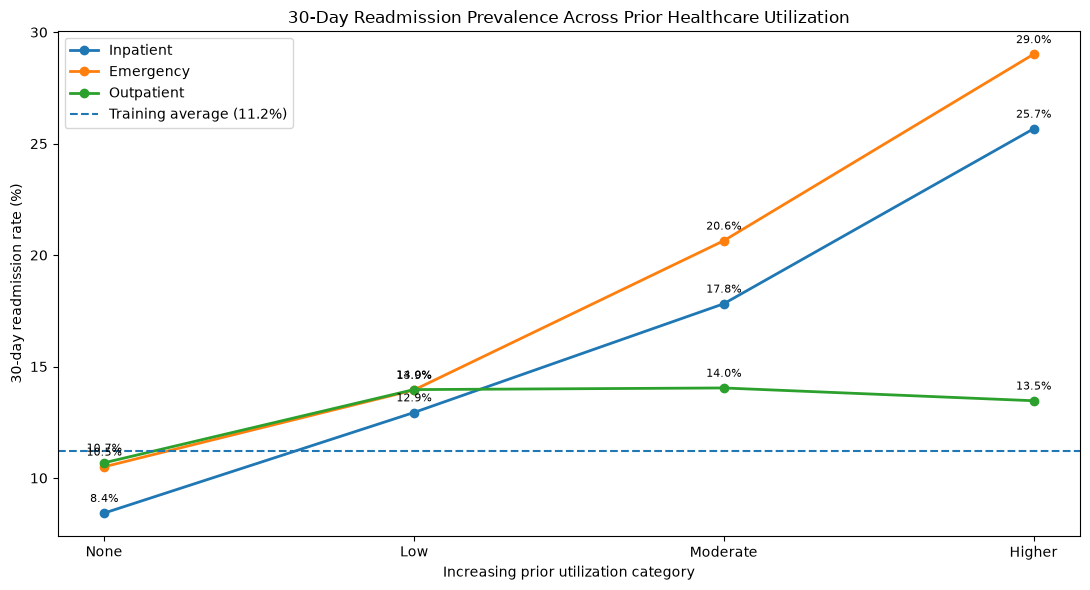

In [39]:
# Visualize utilization-specific readmission gradients

fig, ax = plt.subplots(figsize=(11, 6))

for utilization_type in ["Inpatient", "Emergency", "Outpatient"]:
    subset = utilization_comparison[
        utilization_comparison["utilization_type"] == utilization_type
    ].reset_index(drop=True)

    x_positions = np.arange(len(subset))

    ax.plot(
        x_positions,
        subset["readmission_pct"],
        marker="o",
        linewidth=2,
        label=utilization_type,
    )

    for x_pos, rate in zip(
        x_positions,
        subset["readmission_pct"],
    ):
        ax.text(
            x_pos,
            rate + 0.5,
            f"{rate:.1f}%",
            ha="center",
            fontsize=8,
        )

ax.axhline(
    positive_rate * 100,
    linestyle="--",
    linewidth=1.5,
    label=f"Training average ({positive_rate:.1%})",
)

ax.set_title("30-Day Readmission Prevalence Across Prior Healthcare Utilization")
ax.set_xlabel("Increasing prior utilization category")
ax.set_ylabel("30-day readmission rate (%)")

ax.set_xticks(range(4))
ax.set_xticklabels(
    [
        "None",
        "Low",
        "Moderate",
        "Higher",
    ]
)

ax.legend()

plt.tight_layout()
plt.show()

In [40]:
# Display exact utilization-category definitions

category_definitions = pd.DataFrame(
    {
        "Utilization type": [
            "Inpatient",
            "Emergency",
            "Outpatient",
        ],
        "None": [
            "0 visits",
            "0 visits",
            "0 visits",
        ],
        "Low": [
            "1 visit",
            "1 visit",
            "1 visit",
        ],
        "Moderate": [
            "2 visits",
            "2–3 visits",
            "2–3 visits",
        ],
        "Higher": [
            "3+ visits",
            "4+ visits",
            "4+ visits",
        ],
    }
)

category_definitions

,Utilization type,None,Low,Moderate,Higher
0,Inpatient,0 visits,1 visit,2 visits,3+ visits
1,Emergency,0 visits,1 visit,2–3 visits,4+ visits
2,Outpatient,0 visits,1 visit,2–3 visits,4+ visits


In [41]:
# Quantify observed utilization gradients

gradient_summary = []

for utilization_type in [
    "Inpatient",
    "Emergency",
    "Outpatient",
]:
    subset = utilization_comparison[
        utilization_comparison["utilization_type"] == utilization_type
    ].reset_index(drop=True)

    baseline_rate = subset.loc[0, "readmission_pct"]
    highest_rate = subset.loc[len(subset) - 1, "readmission_pct"]

    absolute_difference = highest_rate - baseline_rate
    relative_ratio = highest_rate / baseline_rate

    gradient_summary.append(
        {
            "utilization_type": utilization_type,
            "baseline_rate_pct": baseline_rate,
            "highest_group_rate_pct": highest_rate,
            "absolute_difference_pp": absolute_difference,
            "highest_vs_baseline_ratio": relative_ratio,
        }
    )

gradient_summary = pd.DataFrame(gradient_summary)

gradient_summary.round(2)

,utilization_type,baseline_rate_pct,highest_group_rate_pct,absolute_difference_pp,highest_vs_baseline_ratio
0,Inpatient,8.4200,25.6600,17.2400,3.0500
1,Emergency,10.5000,29.0100,18.5100,2.7600
2,Outpatient,10.6800,13.4700,2.7800,1.2600


### Comparative utilization interpretation

Prior healthcare utilization shows materially different relationships with 30-day readmission prevalence depending on the type of healthcare encounter.

**Prior inpatient utilization exhibits a strong positive gradient.** Observed readmission prevalence increases from approximately **8.4% among encounters with no prior inpatient visits to 25.7% among the highest-utilization group**, an absolute difference of approximately **17 percentage points**.

**Prior emergency utilization exhibits a similarly strong gradient.** Readmission prevalence increases from approximately **10.5% among encounters with no prior emergency visits to 29.0% among encounters involving patients with four or more prior emergency visits**, representing the highest observed prevalence among the grouped utilization categories examined.

**Prior outpatient utilization behaves differently.** Readmission prevalence increases from approximately **10.7% among patients with no prior outpatient visits to approximately 14% among patients with prior outpatient activity, but does not continue increasing with greater outpatient utilization.**

Taken together, these descriptive results indicate that **recent acute-care utilization history—particularly repeated inpatient and emergency encounters—is substantially more strongly associated with 30-day readmission than outpatient visit frequency alone**. These variables therefore represent important candidate predictors for subsequent multivariable modeling.

The associations are descriptive and should not be interpreted causally. Prior utilization may capture underlying disease burden, clinical instability, healthcare-access patterns, or other patient characteristics that also influence readmission risk.

Taken together, these descriptive results identify a clear distinction between **acute-care utilization** and **outpatient utilization**. Repeated inpatient and emergency encounters exhibit strong positive gradients with 30-day readmission prevalence, whereas outpatient utilization shows only a modest elevation after any prior use and little additional increase at higher utilization levels.

Among the utilization measures examined, prior emergency and inpatient utilization therefore emerge as particularly important candidate predictors for subsequent multivariable modeling. These associations remain descriptive rather than causal and may reflect underlying disease burden, clinical instability, healthcare-access patterns, or other patient characteristics.

# 3F — Clinical Complexity & Diagnoses

Healthcare utilization captures a patient's recent interaction with the healthcare system, but readmission risk may also vary with the clinical complexity of the index encounter.

This section examines diagnostic burden and diagnosis characteristics within the training partition. Analysis begins with the number of documented diagnoses before progressing to clinically meaningful diagnosis families and other indicators of treatment complexity.

## 3F.1 — Diagnostic Burden

The `number_diagnoses` variable represents the number of diagnoses documented for an encounter. This analysis evaluates its distribution and its relationship with observed 30-day readmission prevalence.

In [42]:
# Analyze diagnostic burden

diagnosis_count_analysis = (
    df_train.groupby("number_diagnoses", observed=True)
    .agg(
        encounters=(TARGET, "size"),
        readmissions=(TARGET, "sum"),
        readmission_rate=(TARGET, "mean"),
    )
    .reset_index()
    .sort_values("number_diagnoses")
)

diagnosis_count_analysis["population_pct"] = (
    diagnosis_count_analysis["encounters"] / len(df_train) * 100
)

diagnosis_count_analysis["readmission_pct"] = (
    diagnosis_count_analysis["readmission_rate"] * 100
)

assert diagnosis_count_analysis["encounters"].sum() == len(df_train)
assert diagnosis_count_analysis["readmissions"].sum() == df_train[TARGET].sum()

diagnosis_summary = df_train["number_diagnoses"].describe()

print("Number-of-diagnoses summary")
print("-" * 50)
print(f"Minimum: {int(diagnosis_summary['min'])}")
print(f"Median:  {diagnosis_summary['50%']:.1f}")
print(f"Mean:    {diagnosis_summary['mean']:.2f}")
print(f"Maximum: {int(diagnosis_summary['max'])}")

diagnosis_count_analysis[
    [
        "number_diagnoses",
        "encounters",
        "population_pct",
        "readmissions",
        "readmission_pct",
    ]
]

Number-of-diagnoses summary
--------------------------------------------------
Minimum: 1
Median:  8.0
Mean:    7.43
Maximum: 16


,number_diagnoses,encounters,population_pct,readmissions,readmission_pct
0,1,141,0.1971,10,7.0922
1,2,724,1.0123,49,6.7680
2,3,1965,2.7475,143,7.2774
3,4,3890,5.4390,327,8.4062
4,5,8028,11.2248,731,9.1056
5,6,7108,9.9385,740,10.4108
6,7,7305,10.2139,800,10.9514
7,8,7486,10.4670,880,11.7553
8,9,34784,48.6353,4326,12.4368
9,10,16,0.0224,3,18.7500


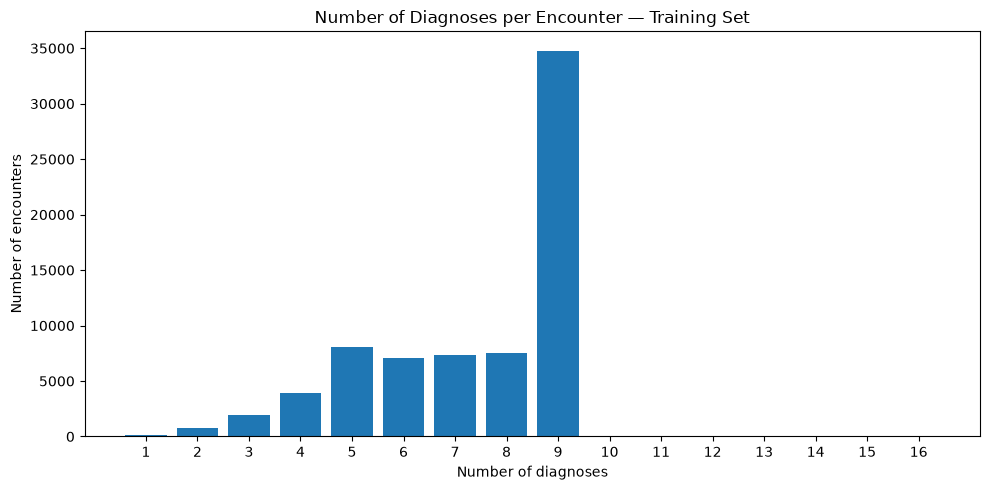

In [43]:
# Visualize diagnostic-burden distribution

fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(
    diagnosis_count_analysis["number_diagnoses"],
    diagnosis_count_analysis["encounters"],
)

ax.set_title("Number of Diagnoses per Encounter — Training Set")
ax.set_xlabel("Number of diagnoses")
ax.set_ylabel("Number of encounters")

ax.set_xticks(diagnosis_count_analysis["number_diagnoses"])

plt.tight_layout()
plt.show()

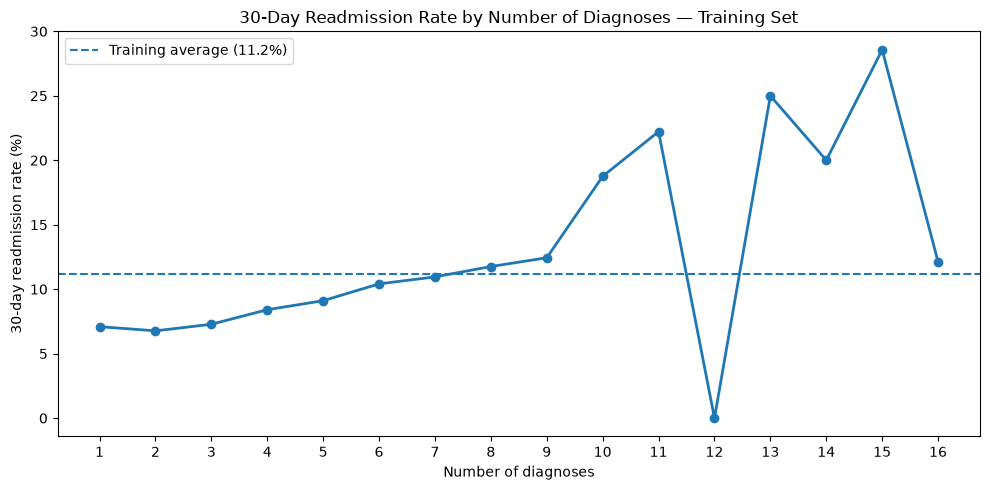

In [44]:
# Visualize readmission prevalence by diagnostic burden

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    diagnosis_count_analysis["number_diagnoses"],
    diagnosis_count_analysis["readmission_pct"],
    marker="o",
    linewidth=2,
)

ax.axhline(
    positive_rate * 100,
    linestyle="--",
    linewidth=1.5,
    label=f"Training average ({positive_rate:.1%})",
)

ax.set_title("30-Day Readmission Rate by Number of Diagnoses — Training Set")
ax.set_xlabel("Number of diagnoses")
ax.set_ylabel("30-day readmission rate (%)")

ax.set_xticks(diagnosis_count_analysis["number_diagnoses"])
ax.legend()

plt.tight_layout()
plt.show()

In [45]:
# Group diagnostic burden into interpretable categories

df_train["diagnosis_burden_group"] = pd.cut(
    df_train["number_diagnoses"],
    bins=[0, 4, 6, 8, np.inf],
    labels=["1–4", "5–6", "7–8", "9+"],
)

diagnosis_group_analysis = (
    df_train.groupby("diagnosis_burden_group", observed=True)
    .agg(
        encounters=(TARGET, "size"),
        readmissions=(TARGET, "sum"),
        readmission_rate=(TARGET, "mean"),
    )
    .reset_index()
)

diagnosis_group_analysis["population_pct"] = (
    diagnosis_group_analysis["encounters"] / len(df_train) * 100
)

diagnosis_group_analysis["readmission_pct"] = (
    diagnosis_group_analysis["readmission_rate"] * 100
)

assert diagnosis_group_analysis["encounters"].sum() == len(df_train)
assert diagnosis_group_analysis["readmissions"].sum() == df_train[TARGET].sum()

diagnosis_group_analysis[
    [
        "diagnosis_burden_group",
        "encounters",
        "population_pct",
        "readmissions",
        "readmission_pct",
    ]
]

,diagnosis_burden_group,encounters,population_pct,readmissions,readmission_pct
0,1–4,6720,9.3960,529,7.8720
1,5–6,15136,21.1633,1471,9.7186
2,7–8,14791,20.6809,1680,11.3583
3,9+,34873,48.7598,4341,12.4480


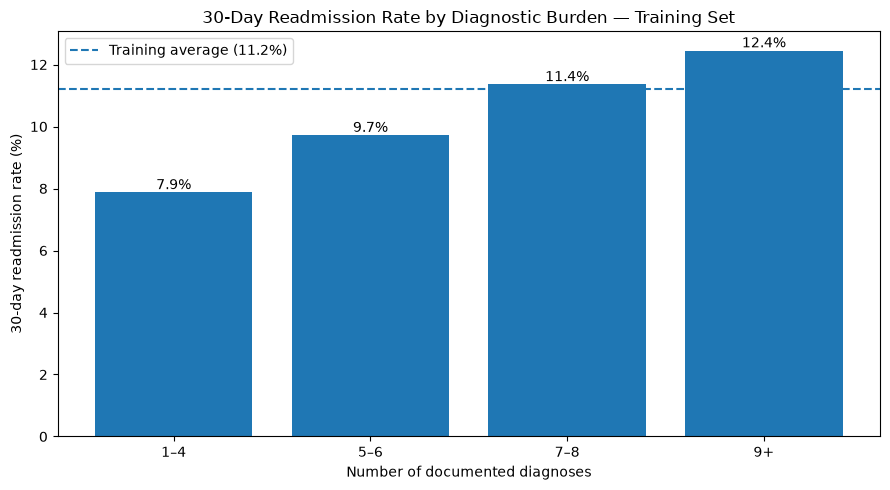

In [46]:
# Visualize grouped diagnostic burden

fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.bar(
    diagnosis_group_analysis["diagnosis_burden_group"].astype(str),
    diagnosis_group_analysis["readmission_pct"],
)

ax.axhline(
    positive_rate * 100,
    linestyle="--",
    linewidth=1.5,
    label=f"Training average ({positive_rate:.1%})",
)

for bar, rate in zip(
    bars,
    diagnosis_group_analysis["readmission_pct"],
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{rate:.1f}%",
        ha="center",
        va="bottom",
    )

ax.set_title("30-Day Readmission Rate by Diagnostic Burden — Training Set")
ax.set_xlabel("Number of documented diagnoses")
ax.set_ylabel("30-day readmission rate (%)")

ax.legend()

plt.tight_layout()
plt.show()

In [47]:
# Show denominator sizes for sparse high-diagnosis values

diagnosis_tail = diagnosis_count_analysis.loc[
    diagnosis_count_analysis["number_diagnoses"] >= 9,
    [
        "number_diagnoses",
        "encounters",
        "readmissions",
        "readmission_pct",
    ],
].copy()

diagnosis_tail

,number_diagnoses,encounters,readmissions,readmission_pct
8,9,34784,4326,12.4368
9,10,16,3,18.7500
10,11,9,2,22.2222
11,12,7,0,0.0000
12,13,12,3,25.0000
13,14,5,1,20.0000
14,15,7,2,28.5714
15,16,33,4,12.1212


### Diagnostic burden interpretation

The number of documented diagnoses shows a positive descriptive association with 30-day readmission prevalence. Across the well-represented portion of the distribution, readmission prevalence generally increases as diagnostic burden rises.

Encounter volume is concentrated at nine or fewer diagnoses, with nine diagnoses representing a particularly large share of the training observations. Individual estimates above this range are substantially more volatile because relatively few encounters occupy some of the highest diagnosis-count values. Consequently, isolated rates in the extreme tail should not be interpreted as evidence of abrupt changes in risk.

To provide a more stable and interpretable comparison, diagnosis counts were therefore summarized into four burden categories: **1–4, 5–6, 7–8, and 9+ diagnoses**. This preserves the observed progression across the well-supported range while preventing sparse high-count values from dominating interpretation.

Overall, the results suggest that greater documented diagnostic complexity may be an informative candidate predictor of 30-day readmission. The relationship remains descriptive and may reflect underlying disease burden, multimorbidity, encounter complexity, coding intensity, or other correlated clinical factors.

## 3F.2 — Primary Diagnosis Clinical Families

The raw `diag_1` field contains ICD-9 diagnosis codes with high cardinality. To support clinically interpretable exploratory analysis, primary diagnosis codes are grouped into broader disease families.

These grouped categories are used for descriptive analysis only; the original diagnosis fields remain available for downstream modeling decisions.

In [48]:
# Map ICD-9 diagnosis codes into broad clinical families


def map_icd9_family(code):
    if pd.isna(code):
        return "Missing"

    code = str(code).strip()

    if code in {"Missing", "Unknown"}:
        return code

    # Handle V and E codes separately
    if code.startswith("V"):
        return "Supplementary factors"
    if code.startswith("E"):
        return "External causes"

    try:
        numeric_code = float(code)
    except ValueError:
        return "Other"

    if 1 <= numeric_code <= 139:
        return "Infectious & parasitic"
    elif 140 <= numeric_code <= 239:
        return "Neoplasms"
    elif 240 <= numeric_code <= 279:
        return "Endocrine, nutritional & metabolic"
    elif 280 <= numeric_code <= 289:
        return "Blood disorders"
    elif 290 <= numeric_code <= 319:
        return "Mental disorders"
    elif 320 <= numeric_code <= 389:
        return "Nervous system & sense organs"
    elif 390 <= numeric_code <= 459:
        return "Circulatory"
    elif 460 <= numeric_code <= 519:
        return "Respiratory"
    elif 520 <= numeric_code <= 579:
        return "Digestive"
    elif 580 <= numeric_code <= 629:
        return "Genitourinary"
    elif 630 <= numeric_code <= 679:
        return "Pregnancy & childbirth"
    elif 680 <= numeric_code <= 709:
        return "Skin & subcutaneous tissue"
    elif 710 <= numeric_code <= 739:
        return "Musculoskeletal & connective tissue"
    elif 740 <= numeric_code <= 759:
        return "Congenital anomalies"
    elif 760 <= numeric_code <= 779:
        return "Perinatal conditions"
    elif 780 <= numeric_code <= 799:
        return "Symptoms & ill-defined conditions"
    elif 800 <= numeric_code <= 999:
        return "Injury & poisoning"
    else:
        return "Other"

In [49]:
# Create primary-diagnosis clinical family

df_train["diag_1_family"] = df_train["diag_1"].apply(map_icd9_family)

diag1_family_analysis = (
    df_train.groupby("diag_1_family", observed=True)
    .agg(
        encounters=(TARGET, "size"),
        readmissions=(TARGET, "sum"),
        readmission_rate=(TARGET, "mean"),
    )
    .reset_index()
)

diag1_family_analysis["population_pct"] = (
    diag1_family_analysis["encounters"] / len(df_train) * 100
)

diag1_family_analysis["readmission_pct"] = (
    diag1_family_analysis["readmission_rate"] * 100
)

diag1_family_analysis = diag1_family_analysis.sort_values(
    "encounters", ascending=False
).reset_index(drop=True)

assert diag1_family_analysis["encounters"].sum() == len(df_train)
assert diag1_family_analysis["readmissions"].sum() == df_train[TARGET].sum()

diag1_family_analysis[
    [
        "diag_1_family",
        "encounters",
        "population_pct",
        "readmissions",
        "readmission_pct",
    ]
]

,diag_1_family,encounters,population_pct,readmissions,readmission_pct
0,Circulatory,21430,29.9636,2477,11.5586
1,"Endocrine, nutritional & metabolic",8156,11.4038,1081,13.2540
2,Respiratory,7295,10.1999,774,10.6100
3,Digestive,6411,8.9639,698,10.8875
4,Symptoms & ill-defined conditions,5299,7.4091,476,8.9828
5,Injury & poisoning,4919,6.8778,599,12.1773
6,Genitourinary,3546,4.9581,379,10.6881
7,Musculoskeletal & connective tissue,3405,4.7609,319,9.3686
8,Neoplasms,2399,3.3543,228,9.5040
9,Infectious & parasitic,1926,2.6930,213,11.0592


In [50]:
# 3F.2A Display primary-diagnosis families with readable percentages

diag1_display = diag1_family_analysis[
    [
        "diag_1_family",
        "encounters",
        "population_pct",
        "readmissions",
        "readmission_pct",
    ]
].copy()

diag1_display["population_pct"] = diag1_display["population_pct"].round(2)
diag1_display["readmission_pct"] = diag1_display["readmission_pct"].round(2)

print("Primary diagnosis family summary")
print("-" * 85)

for _, row in diag1_display.iterrows():
    print(
        f"{row['diag_1_family']:<38} "
        f"n={int(row['encounters']):>6,} | "
        f"population={row['population_pct']:>5.2f}% | "
        f"readmission={row['readmission_pct']:>5.2f}%"
    )

diag1_display

Primary diagnosis family summary
-------------------------------------------------------------------------------------
Circulatory                            n=21,430 | population=29.96% | readmission=11.56%
Endocrine, nutritional & metabolic     n= 8,156 | population=11.40% | readmission=13.25%
Respiratory                            n= 7,295 | population=10.20% | readmission=10.61%
Digestive                              n= 6,411 | population= 8.96% | readmission=10.89%
Symptoms & ill-defined conditions      n= 5,299 | population= 7.41% | readmission= 8.98%
Injury & poisoning                     n= 4,919 | population= 6.88% | readmission=12.18%
Genitourinary                          n= 3,546 | population= 4.96% | readmission=10.69%
Musculoskeletal & connective tissue    n= 3,405 | population= 4.76% | readmission= 9.37%
Neoplasms                              n= 2,399 | population= 3.35% | readmission= 9.50%
Infectious & parasitic                 n= 1,926 | population= 2.69% | readmissio

,diag_1_family,encounters,population_pct,readmissions,readmission_pct
0,Circulatory,21430,29.9600,2477,11.5600
1,"Endocrine, nutritional & metabolic",8156,11.4000,1081,13.2500
2,Respiratory,7295,10.2000,774,10.6100
3,Digestive,6411,8.9600,698,10.8900
4,Symptoms & ill-defined conditions,5299,7.4100,476,8.9800
5,Injury & poisoning,4919,6.8800,599,12.1800
6,Genitourinary,3546,4.9600,379,10.6900
7,Musculoskeletal & connective tissue,3405,4.7600,319,9.3700
8,Neoplasms,2399,3.3500,228,9.5000
9,Infectious & parasitic,1926,2.6900,213,11.0600


In [51]:
# 3F.2B Restrict diagnosis-family visualization to adequately represented groups

MIN_DIAG_FAMILY_N = 500

diag1_plot = (
    diag1_family_analysis[diag1_family_analysis["encounters"] >= MIN_DIAG_FAMILY_N]
    .sort_values("readmission_pct")
    .copy()
)

print(
    f"Diagnosis families displayed: {len(diag1_plot)} "
    f"of {len(diag1_family_analysis)}"
)
print(f"Minimum encounter threshold: {MIN_DIAG_FAMILY_N:,}")

diag1_plot[
    [
        "diag_1_family",
        "encounters",
        "readmission_pct",
    ]
]

Diagnosis families displayed: 15 of 18
Minimum encounter threshold: 500


,diag_1_family,encounters,readmission_pct
4,Symptoms & ill-defined conditions,5299,8.9828
7,Musculoskeletal & connective tissue,3405,9.3686
8,Neoplasms,2399,9.5040
10,Skin & subcutaneous tissue,1830,10.1093
13,Nervous system & sense organs,855,10.4094
2,Respiratory,7295,10.6100
6,Genitourinary,3546,10.6881
3,Digestive,6411,10.8875
9,Infectious & parasitic,1926,11.0592
0,Circulatory,21430,11.5586


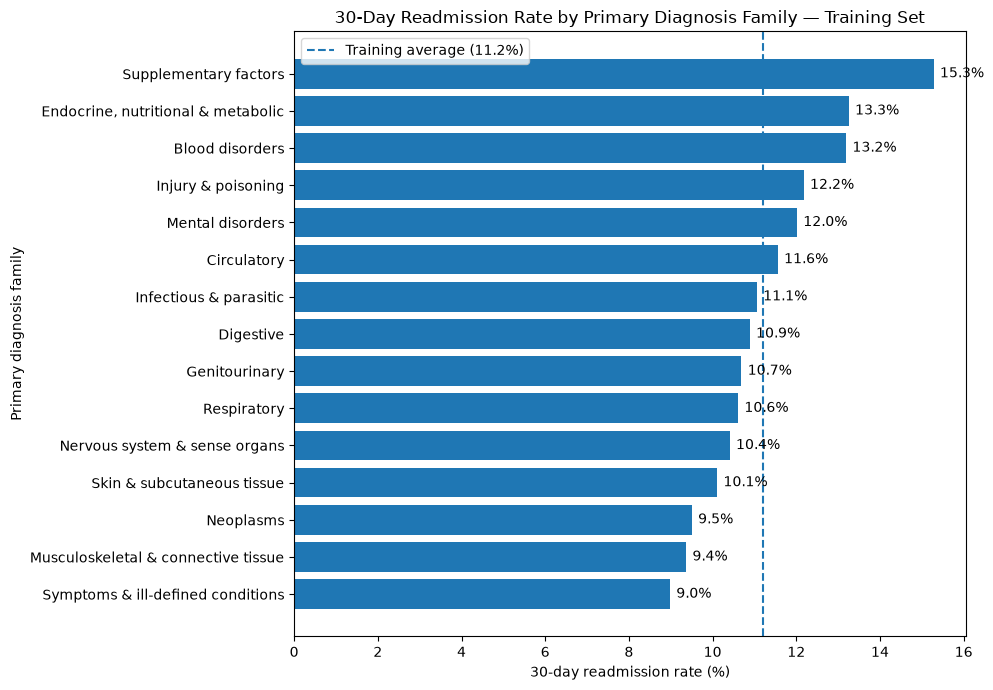

In [52]:
# Visualize readmission prevalence across major primary-diagnosis families

fig, ax = plt.subplots(figsize=(10, 7))

bars = ax.barh(
    diag1_plot["diag_1_family"],
    diag1_plot["readmission_pct"],
)

ax.axvline(
    positive_rate * 100,
    linestyle="--",
    linewidth=1.5,
    label=f"Training average ({positive_rate:.1%})",
)

for bar, rate in zip(
    bars,
    diag1_plot["readmission_pct"],
):
    ax.text(
        bar.get_width() + 0.15,
        bar.get_y() + bar.get_height() / 2,
        f"{rate:.1f}%",
        va="center",
    )

ax.set_title("30-Day Readmission Rate by Primary Diagnosis Family — Training Set")
ax.set_xlabel("30-day readmission rate (%)")
ax.set_ylabel("Primary diagnosis family")

ax.legend()

plt.tight_layout()
plt.show()

### Primary diagnosis family interpretation

Primary diagnosis families show meaningful variation in observed 30-day readmission prevalence.

Among adequately represented diagnosis families, the highest observed rates occur for **supplementary factors**, **endocrine, nutritional and metabolic disorders**, and **blood disorders**, all above the overall training-set prevalence of approximately **11.2%**. Injury and poisoning, mental disorders, and circulatory diagnoses also exhibit moderately elevated readmission prevalence.

Importantly, diagnosis-family prevalence and readmission risk are not equivalent. Circulatory diagnoses represent the largest share of encounters in the training data, yet their readmission rate is only modestly above the overall average. Conversely, some less common diagnosis families exhibit higher observed readmission prevalence.

Several diagnosis families fall below the training baseline, including neoplasms, musculoskeletal and connective-tissue disorders, and symptoms or ill-defined conditions.

These results indicate that broad primary-diagnosis categories may provide clinically meaningful predictive information beyond simple encounter volume. However, the observed differences are descriptive and may reflect differences in disease severity, comorbidity burden, coding practices, treatment pathways, or patient case mix rather than causal effects of diagnosis category itself.

In [53]:
# Create secondary and tertiary diagnosis families

df_train["diag_2_family"] = df_train["diag_2"].apply(map_icd9_family)
df_train["diag_3_family"] = df_train["diag_3"].apply(map_icd9_family)


def summarize_diagnosis_family(df, family_column, label):
    summary = (
        df.groupby(family_column, observed=True)
        .agg(
            encounters=(TARGET, "size"),
            readmissions=(TARGET, "sum"),
            readmission_rate=(TARGET, "mean"),
        )
        .reset_index()
        .rename(columns={family_column: "diagnosis_family"})
    )

    summary["population_pct"] = summary["encounters"] / len(df) * 100

    summary["readmission_pct"] = summary["readmission_rate"] * 100

    summary["diagnosis_position"] = label

    return summary


diag2_family_analysis = summarize_diagnosis_family(
    df_train,
    "diag_2_family",
    "Secondary",
)

diag3_family_analysis = summarize_diagnosis_family(
    df_train,
    "diag_3_family",
    "Tertiary",
)

diag23_analysis = pd.concat(
    [diag2_family_analysis, diag3_family_analysis],
    ignore_index=True,
)

diag23_analysis

,diagnosis_family,encounters,readmissions,readmission_rate,population_pct,readmission_pct,diagnosis_position
0,Blood disorders,2041,192,0.0941,2.8537,9.4072,Secondary
1,Circulatory,22069,2476,0.1122,30.8571,11.2194,Secondary
2,Congenital anomalies,85,6,0.0706,0.1188,7.0588,Secondary
3,Digestive,2753,314,0.1141,3.8493,11.4057,Secondary
4,"Endocrine, nutritional & metabolic",14784,1592,0.1077,20.6711,10.7684,Secondary
5,External causes,524,75,0.1431,0.7327,14.3130,Secondary
6,Genitourinary,5617,679,0.1209,7.8537,12.0883,Secondary
7,Infectious & parasitic,1379,168,0.1218,1.9281,12.1827,Secondary
8,Injury & poisoning,1694,193,0.1139,2.3686,11.3932,Secondary
9,Mental disorders,1866,216,0.1158,2.6091,11.5756,Secondary


In [54]:
# Inspect secondary and tertiary diagnosis-family coverage

for position, family_col in [
    ("Secondary", "diag_2_family"),
    ("Tertiary", "diag_3_family"),
]:
    counts = df_train[family_col].value_counts(dropna=False)

    print(position)
    print("-" * 40)
    print(counts.head(10))
    print()

Secondary
----------------------------------------
diag_2_family
Circulatory                           22069
Endocrine, nutritional & metabolic    14784
Respiratory                            7208
Genitourinary                          5617
Symptoms & ill-defined conditions      3262
Digestive                              2753
Skin & subcutaneous tissue             2579
Blood disorders                        2041
Mental disorders                       1866
Neoplasms                              1741
Name: count, dtype: int64

Tertiary
----------------------------------------
diag_3_family
Circulatory                           20947
Endocrine, nutritional & metabolic    18516
Respiratory                            4808
Genitourinary                          4497
Symptoms & ill-defined conditions      3145
Supplementary factors                  2676
Digestive                              2521
Mental disorders                       2206
Blood disorders                        1778
Skin & s

In [55]:
# 3F.3 Summarize primary diagnosis using the same structure

diag1_position = diag1_family_analysis.rename(
    columns={"diag_1_family": "diagnosis_family"}
).copy()

diag1_position["diagnosis_position"] = "Primary"

# Standardize column structure
diag1_position = diag1_position[
    [
        "diagnosis_family",
        "encounters",
        "readmissions",
        "readmission_rate",
        "population_pct",
        "readmission_pct",
        "diagnosis_position",
    ]
]

diagnosis_position_analysis = pd.concat(
    [
        diag1_position,
        diag2_family_analysis,
        diag3_family_analysis,
    ],
    ignore_index=True,
)

# Restrict comparison to adequately represented clinical families
diagnosis_position_plot = diagnosis_position_analysis[
    diagnosis_position_analysis["encounters"] >= 500
].copy()

diagnosis_position_analysis.shape, diagnosis_position_plot.shape

((56, 7), (48, 7))

In [56]:
# Compare prevalence of major diagnosis families by diagnosis position

major_families = [
    "Circulatory",
    "Endocrine, nutritional & metabolic",
    "Respiratory",
    "Genitourinary",
    "Digestive",
    "Symptoms & ill-defined conditions",
]

diagnosis_position_comparison = (
    diagnosis_position_analysis[
        diagnosis_position_analysis["diagnosis_family"].isin(major_families)
    ]
    .pivot(
        index="diagnosis_family",
        columns="diagnosis_position",
        values=["population_pct", "readmission_pct"],
    )
    .round(2)
)

diagnosis_position_comparison

population_pct                     \
diagnosis_position                        Primary Secondary Tertiary   
diagnosis_family                                                       
Circulatory                               29.9600   30.8600  29.2900   
Digestive                                  8.9600    3.8500   3.5200   
Endocrine, nutritional & metabolic        11.4000   20.6700  25.8900   
Genitourinary                              4.9600    7.8500   6.2900   
Respiratory                               10.2000   10.0800   6.7200   
Symptoms & ill-defined conditions          7.4100    4.5600   4.4000   

                                   readmission_pct                     
diagnosis_position                         Primary Secondary Tertiary  
diagnosis_family                                                       
Circulatory                                11.5600   11.2200  11.0000  
Digestive                                  10.8900   11.4100  12.1000  
Endocrine, nutritional & metabolic         13.2500   10.7700  10.5600  
Genitourinary                              10.6900   12.0900  13.9000  
Respiratory                                10.6100   10.8600  12.5400  
Symptoms & ill-defined conditions           8.9800   10.4800  12.0500

### 3F.3 Secondary and tertiary diagnosis interpretation

Secondary and tertiary diagnoses show substantial clinical structure rather than functioning primarily as missing or sparse fields. Circulatory and endocrine/metabolic conditions are especially prominent across diagnosis positions.

The relative prominence of diagnosis families changes across diagnostic position. In particular, endocrine, nutritional and metabolic diagnoses become increasingly common among secondary and tertiary diagnoses, consistent with the substantial comorbidity burden expected within this diabetic inpatient population.

Because diagnosis position reflects clinical documentation and coding hierarchy rather than independent disease processes, primary, secondary and tertiary diagnoses should not be interpreted as three unrelated predictors. Their combined patterns instead provide evidence that both the principal reason for hospitalization and accompanying comorbid conditions may contribute useful information for downstream readmission modeling.

These associations remain descriptive and may reflect disease severity, multimorbidity, documentation practices, or differences in patient case mix.

### 3F.4 Treatment & Encounter Complexity

Treatment intensity may provide additional information about the clinical
complexity of an encounter beyond diagnosis burden alone. This section examines
the number of procedures performed and the number of medications documented
during the encounter.

These variables are interpreted as descriptive proxies for treatment and
encounter complexity rather than direct measures of disease severity.

In [57]:
# Examine procedure burden

procedure_analysis = (
    df_train.groupby("num_procedures", observed=True)
    .agg(
        encounters=(TARGET, "size"),
        readmissions=(TARGET, "sum"),
        readmission_rate=(TARGET, "mean"),
    )
    .reset_index()
)

procedure_analysis["population_pct"] = (
    procedure_analysis["encounters"] / len(df_train) * 100
)

procedure_analysis["readmission_pct"] = procedure_analysis["readmission_rate"] * 100

procedure_analysis = procedure_analysis.sort_values("num_procedures").reset_index(
    drop=True
)

assert procedure_analysis["encounters"].sum() == len(df_train)
assert procedure_analysis["readmissions"].sum() == df_train[TARGET].sum()

procedure_summary = df_train["num_procedures"].describe()

print("Number-of-procedures summary")
print("-" * 45)
print(f"Minimum: {procedure_summary['min']:.0f}")
print(f"Median:  {procedure_summary['50%']:.0f}")
print(f"Mean:    {procedure_summary['mean']:.2f}")
print(f"Maximum: {procedure_summary['max']:.0f}")

procedure_analysis[
    [
        "num_procedures",
        "encounters",
        "population_pct",
        "readmissions",
        "readmission_pct",
    ]
]

Number-of-procedures summary
---------------------------------------------
Minimum: 0
Median:  1
Mean:    1.34
Maximum: 6


,num_procedures,encounters,population_pct,readmissions,readmission_pct
0,0,32924,46.0347,3692,11.2137
1,1,14511,20.2894,1754,12.0874
2,2,8920,12.4720,1014,11.3677
3,3,6545,9.1513,700,10.6952
4,4,2978,4.1639,319,10.7119
5,5,2162,3.0229,203,9.3895
6,6,3480,4.8658,339,9.7414


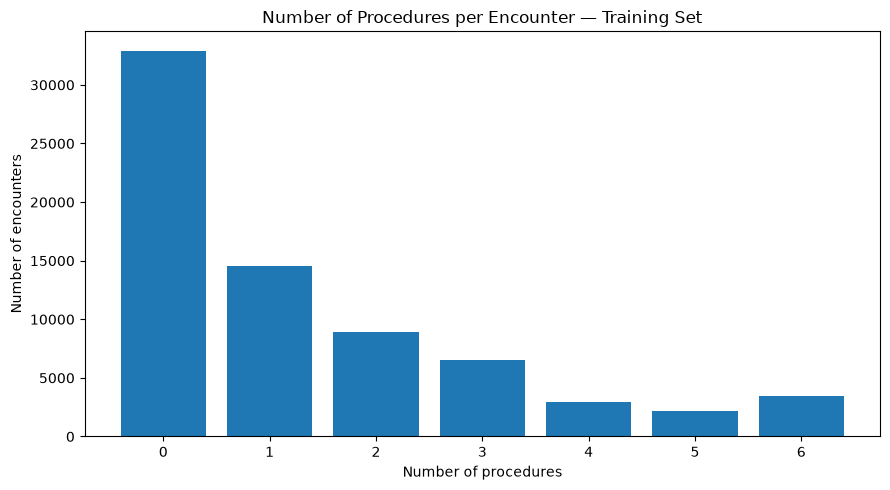

In [58]:
# Visualize procedure-burden distribution

fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.bar(
    procedure_analysis["num_procedures"].astype(str),
    procedure_analysis["encounters"],
)

ax.set_title("Number of Procedures per Encounter — Training Set")
ax.set_xlabel("Number of procedures")
ax.set_ylabel("Number of encounters")

plt.tight_layout()
plt.show()

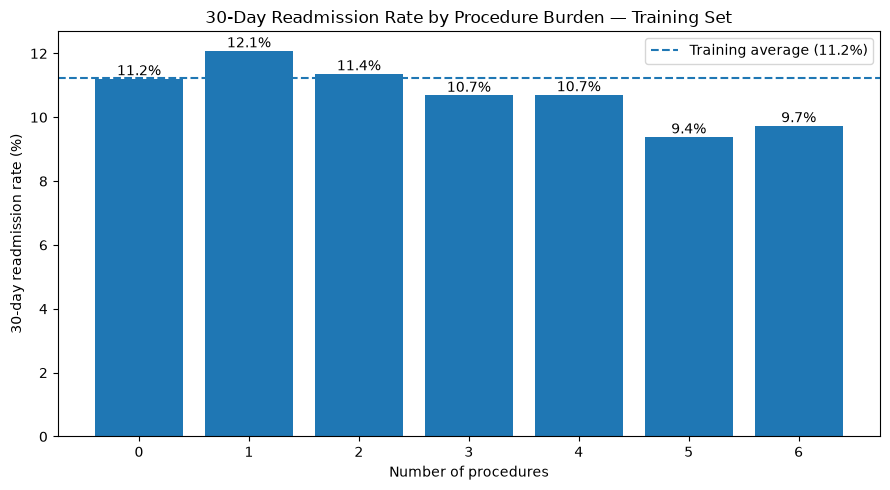

In [59]:
# Visualize readmission prevalence by procedure burden

fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.bar(
    procedure_analysis["num_procedures"].astype(str),
    procedure_analysis["readmission_pct"],
)

ax.axhline(
    positive_rate * 100,
    linestyle="--",
    linewidth=1.5,
    label=f"Training average ({positive_rate:.1%})",
)

for bar, rate in zip(
    bars,
    procedure_analysis["readmission_pct"],
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{rate:.1f}%",
        ha="center",
        va="bottom",
    )

ax.set_title("30-Day Readmission Rate by Procedure Burden — Training Set")
ax.set_xlabel("Number of procedures")
ax.set_ylabel("30-day readmission rate (%)")
ax.legend()

plt.tight_layout()
plt.show()

#### Procedure burden interpretation

Procedure count shows a comparatively weak and non-monotonic relationship with
30-day readmission. The observed readmission rate is highest among encounters
with one documented procedure (12.1%), compared with an overall training
prevalence of approximately 11.2%, while encounters involving five or six
procedures exhibit lower observed rates of approximately 9–10%.

Unlike prior inpatient and emergency utilization, increasing procedure count
does not correspond to a consistent increase in readmission prevalence.
Procedure burden therefore appears to provide substantially weaker univariate
risk separation in this training sample.

Because procedure counts range only from 0 to 6 and each value retains meaningful
representation, no additional grouping is required for descriptive analysis.
The original numeric feature should be retained for subsequent modeling, where
potential nonlinear effects can be evaluated rather than assuming a strictly
linear relationship.

Procedure count should be interpreted as an encounter-level treatment measure
rather than a direct indicator of disease severity; differences may also reflect
the type of admission, diagnosis, treatment pathway, and other clinical factors.

In [60]:
# Examine medication burden

medication_analysis = (
    df_train.groupby("num_medications", observed=True)
    .agg(
        encounters=(TARGET, "size"),
        readmissions=(TARGET, "sum"),
        readmission_rate=(TARGET, "mean"),
    )
    .reset_index()
)

medication_analysis["population_pct"] = (
    medication_analysis["encounters"] / len(df_train) * 100
)

medication_analysis["readmission_pct"] = medication_analysis["readmission_rate"] * 100

medication_analysis = medication_analysis.sort_values("num_medications").reset_index(
    drop=True
)

assert medication_analysis["encounters"].sum() == len(df_train)
assert medication_analysis["readmissions"].sum() == df_train[TARGET].sum()

medication_summary = df_train["num_medications"].describe()

print("Number-of-medications summary")
print("-" * 50)
print(f"Minimum: {medication_summary['min']:.0f}")
print(f"25th pct: {medication_summary['25%']:.0f}")
print(f"Median:  {medication_summary['50%']:.0f}")
print(f"Mean:    {medication_summary['mean']:.2f}")
print(f"75th pct: {medication_summary['75%']:.0f}")
print(f"Maximum: {medication_summary['max']:.0f}")
print()

medication_analysis[
    [
        "num_medications",
        "encounters",
        "population_pct",
        "readmissions",
        "readmission_pct",
    ]
]

Number-of-medications summary
--------------------------------------------------
Minimum: 1
25th pct: 10
Median:  15
Mean:    16.01
75th pct: 20
Maximum: 81



,num_medications,encounters,population_pct,readmissions,readmission_pct
0,1,179,0.2503,7,3.9106
1,2,325,0.4544,27,8.3077
2,3,624,0.8725,43,6.8910
3,4,952,1.3311,82,8.6134
4,5,1417,1.9813,113,7.9746
5,6,1912,2.6734,159,8.3159
6,7,2494,3.4871,223,8.9415
7,8,3097,4.3303,307,9.9128
8,9,3423,4.7861,339,9.9036
9,10,3777,5.2810,374,9.9020


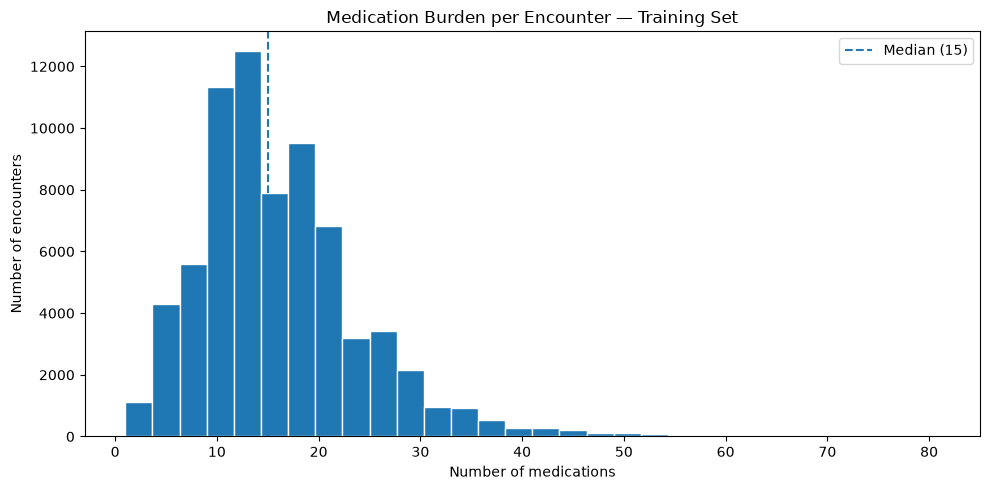

In [61]:
# Visualize medication-burden distribution

fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(
    df_train["num_medications"],
    bins=30,
    edgecolor="white",
)

ax.axvline(
    df_train["num_medications"].median(),
    linestyle="--",
    linewidth=1.5,
    label=f"Median ({df_train['num_medications'].median():.0f})",
)

ax.set_title("Medication Burden per Encounter — Training Set")
ax.set_xlabel("Number of medications")
ax.set_ylabel("Number of encounters")
ax.legend()

plt.tight_layout()
plt.show()

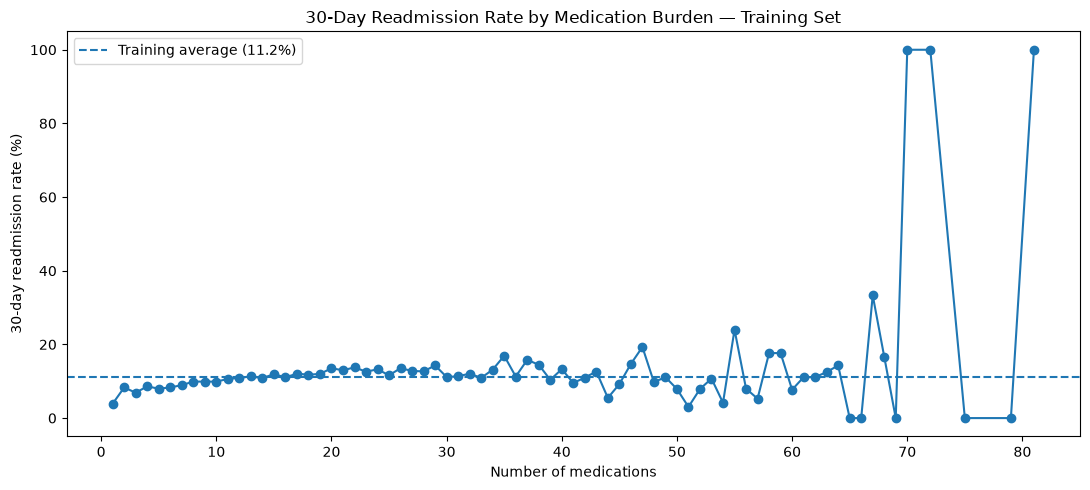

In [62]:
# Visualize raw readmission prevalence by medication burden

fig, ax = plt.subplots(figsize=(11, 5))

ax.plot(
    medication_analysis["num_medications"],
    medication_analysis["readmission_pct"],
    marker="o",
    linewidth=1.5,
)

ax.axhline(
    positive_rate * 100,
    linestyle="--",
    linewidth=1.5,
    label=f"Training average ({positive_rate:.1%})",
)

ax.set_title("30-Day Readmission Rate by Medication Burden — Training Set")
ax.set_xlabel("Number of medications")
ax.set_ylabel("30-day readmission rate (%)")
ax.legend()

plt.tight_layout()
plt.show()

In [63]:
# Inspect denominator sizes across medication counts

medication_tail = medication_analysis[
    [
        "num_medications",
        "encounters",
        "readmissions",
        "readmission_pct",
    ]
].copy()

print("Medication-count denominator inspection")
print("-" * 55)

display(medication_tail)

print()
print(
    "Counts with fewer than 100 encounters:",
    (medication_tail["encounters"] < 100).sum(),
)
print(
    "Counts with fewer than 50 encounters:",
    (medication_tail["encounters"] < 50).sum(),
)

Medication-count denominator inspection
-------------------------------------------------------


,num_medications,encounters,readmissions,readmission_pct
0,1,179,7,3.9106
1,2,325,27,8.3077
2,3,624,43,6.8910
3,4,952,82,8.6134
4,5,1417,113,7.9746
5,6,1912,159,8.3159
6,7,2494,223,8.9415
7,8,3097,307,9.9128
8,9,3423,339,9.9036
9,10,3777,374,9.9020



Counts with fewer than 100 encounters: 33
Counts with fewer than 50 encounters: 27


In [64]:
# Group medication burden into interpretable treatment-complexity categories

df_train["medication_burden_group"] = pd.cut(
    df_train["num_medications"],
    bins=[0, 10, 20, 30, np.inf],
    labels=["1–10", "11–20", "21–30", "31+"],
)

medication_group_analysis = (
    df_train.groupby("medication_burden_group", observed=True)
    .agg(
        encounters=(TARGET, "size"),
        readmissions=(TARGET, "sum"),
        readmission_rate=(TARGET, "mean"),
    )
    .reset_index()
)

medication_group_analysis["population_pct"] = (
    medication_group_analysis["encounters"] / len(df_train) * 100
)

medication_group_analysis["readmission_pct"] = (
    medication_group_analysis["readmission_rate"] * 100
)

assert medication_group_analysis["encounters"].sum() == len(df_train)
assert medication_group_analysis["readmissions"].sum() == df_train[TARGET].sum()

medication_group_analysis[
    [
        "medication_burden_group",
        "encounters",
        "population_pct",
        "readmissions",
        "readmission_pct",
    ]
]

,medication_burden_group,encounters,population_pct,readmissions,readmission_pct
0,1–10,18200,25.4474,1674,9.1978
1,11–20,36608,51.1857,4209,11.4975
2,21–30,13034,18.2243,1687,12.9431
3,31+,3678,5.1426,451,12.2621


In [65]:
print("Grouped medication burden")
print("-" * 70)

for _, row in medication_group_analysis.iterrows():
    print(
        f"{str(row['medication_burden_group']):>5} medications | "
        f"encounters={int(row['encounters']):>6,} | "
        f"readmissions={int(row['readmissions']):>5,} | "
        f"rate={row['readmission_pct']:>5.1f}%"
    )

Grouped medication burden
----------------------------------------------------------------------
 1–10 medications | encounters=18,200 | readmissions=1,674 | rate=  9.2%
11–20 medications | encounters=36,608 | readmissions=4,209 | rate= 11.5%
21–30 medications | encounters=13,034 | readmissions=1,687 | rate= 12.9%
  31+ medications | encounters= 3,678 | readmissions=  451 | rate= 12.3%


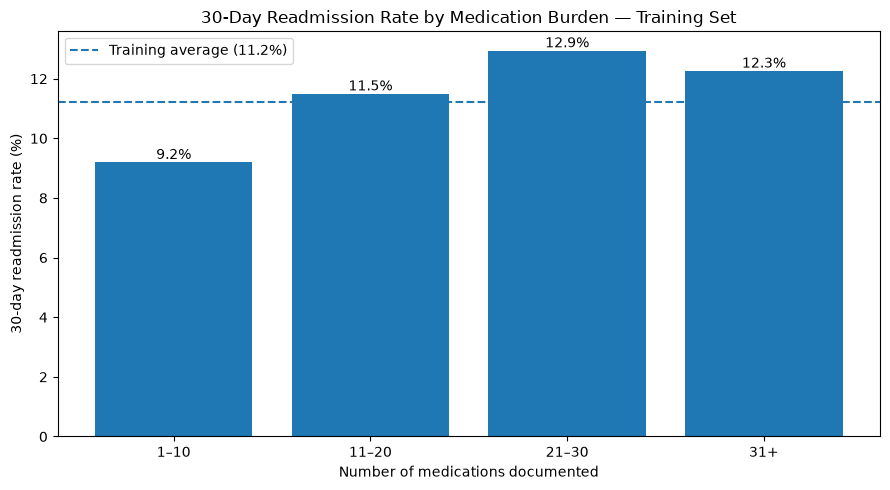

In [66]:
# Visualize grouped medication burden and 30-day readmission

fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.bar(
    medication_group_analysis["medication_burden_group"].astype(str),
    medication_group_analysis["readmission_pct"],
)

ax.axhline(
    positive_rate * 100,
    linestyle="--",
    linewidth=1.5,
    label=f"Training average ({positive_rate:.1%})",
)

for bar, rate in zip(
    bars,
    medication_group_analysis["readmission_pct"],
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{rate:.1f}%",
        ha="center",
        va="bottom",
    )

ax.set_title("30-Day Readmission Rate by Medication Burden — Training Set")
ax.set_xlabel("Number of medications documented")
ax.set_ylabel("30-day readmission rate (%)")
ax.legend()

plt.tight_layout()
plt.show()

#### Medication burden interpretation

Medication burden exhibits a meaningful but nonlinear association with 30-day
readmission. Encounters documenting 1–10 medications have an observed
readmission rate of approximately 9.2%, below the overall training prevalence
of 11.2%. The rate increases to 11.5% among encounters with 11–20 medications
and reaches 12.9% among those with 21–30 medications.

The highest medication-burden group (31+) remains above the training average at
12.3%, although its rate is slightly lower than the 21–30 group. The relationship
therefore appears to increase across low-to-moderately high medication burden
before plateauing rather than following a strictly linear dose-response pattern.

The grouped analysis is preferable to interpreting individual high medication
counts because the raw upper tail contains many sparsely represented values.
All four grouped categories retain substantial encounter counts, producing more
stable descriptive estimates.

Medication count may capture aspects of treatment and clinical complexity and
should be retained for subsequent modeling. However, the association should not
be interpreted as evidence that medication burden itself causes readmission.
Medication count may reflect underlying disease burden, multimorbidity, length
of stay, and treatment intensity. The original numeric feature should therefore
also be retained so nonlinear effects and interactions can be evaluated during
model development.

### 3F.5 Treatment Modification and Diabetes Medication Status

Medication-management variables may capture whether treatment was actively
modified during the encounter and whether diabetes pharmacotherapy was part of
the patient's documented treatment.

This section examines treatment-change status and diabetes-medication status in
relation to 30-day readmission. These variables are interpreted descriptively
and do not establish whether medication changes themselves increase or decrease
subsequent readmission risk.

In [67]:
# Inspect treatment-management variables

for column in ["change", "diabetesMed"]:
    print(column)
    print("-" * 40)
    print(df_train[column].value_counts(dropna=False))
    print()

change
----------------------------------------
change
No    38519
Ch    33001
Name: count, dtype: int64

diabetesMed
----------------------------------------
diabetesMed
Yes    55113
No     16407
Name: count, dtype: int64



In [68]:
# Analyze medication-change status

change_analysis = (
    df_train.groupby("change", observed=True)
    .agg(
        encounters=(TARGET, "size"),
        readmissions=(TARGET, "sum"),
        readmission_rate=(TARGET, "mean"),
    )
    .reset_index()
)

change_analysis["population_pct"] = change_analysis["encounters"] / len(df_train) * 100

change_analysis["readmission_pct"] = change_analysis["readmission_rate"] * 100

assert change_analysis["encounters"].sum() == len(df_train)
assert change_analysis["readmissions"].sum() == df_train[TARGET].sum()

change_analysis[
    [
        "change",
        "encounters",
        "population_pct",
        "readmissions",
        "readmission_pct",
    ]
]

,change,encounters,population_pct,readmissions,readmission_pct
0,Ch,33001,46.1423,3912,11.8542
1,No,38519,53.8577,4109,10.6675


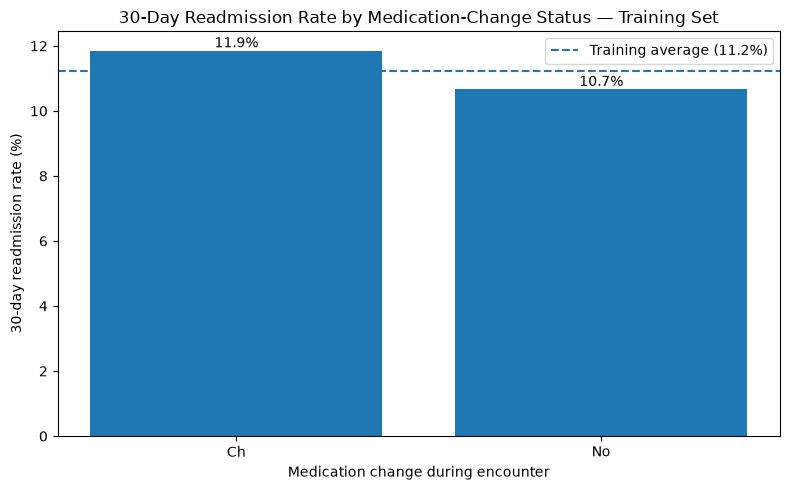

In [69]:
# Visualize readmission prevalence by medication-change status

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    change_analysis["change"].astype(str),
    change_analysis["readmission_pct"],
)

ax.axhline(
    positive_rate * 100,
    linestyle="--",
    linewidth=1.5,
    label=f"Training average ({positive_rate:.1%})",
)

for bar, rate in zip(
    bars,
    change_analysis["readmission_pct"],
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{rate:.1f}%",
        ha="center",
        va="bottom",
    )

ax.set_title("30-Day Readmission Rate by Medication-Change Status — Training Set")
ax.set_xlabel("Medication change during encounter")
ax.set_ylabel("30-day readmission rate (%)")
ax.legend()

plt.tight_layout()
plt.show()

#### Medication-change interpretation

Encounters involving a documented medication change show a modestly higher
30-day readmission prevalence than encounters without a medication change.
The observed readmission rate is approximately 11.9% when medication therapy
was changed compared with 10.7% when no change was documented, versus an
overall training prevalence of 11.2%.

Both categories contain large numbers of encounters, indicating that the
difference is not driven by sparse groups. However, medication modification
should not be interpreted as causing readmission. Treatment changes may instead
identify patients requiring greater therapeutic adjustment because of disease
severity, inadequate control, treatment complexity, or other clinical factors.

The `change` variable should therefore be retained as a candidate predictor and
evaluated alongside medication burden, diagnostic burden, prior utilization,
and other measures of encounter complexity during multivariable modeling.

In [70]:
# Analyze diabetes-medication status

diabetes_med_analysis = (
    df_train.groupby("diabetesMed", observed=True)
    .agg(
        encounters=(TARGET, "size"),
        readmissions=(TARGET, "sum"),
        readmission_rate=(TARGET, "mean"),
    )
    .reset_index()
)

diabetes_med_analysis["population_pct"] = (
    diabetes_med_analysis["encounters"] / len(df_train) * 100
)

diabetes_med_analysis["readmission_pct"] = (
    diabetes_med_analysis["readmission_rate"] * 100
)

assert diabetes_med_analysis["encounters"].sum() == len(df_train)
assert diabetes_med_analysis["readmissions"].sum() == df_train[TARGET].sum()

diabetes_med_analysis[
    [
        "diabetesMed",
        "encounters",
        "population_pct",
        "readmissions",
        "readmission_pct",
    ]
]

,diabetesMed,encounters,population_pct,readmissions,readmission_pct
0,No,16407,22.9404,1562,9.5203
1,Yes,55113,77.0596,6459,11.7196


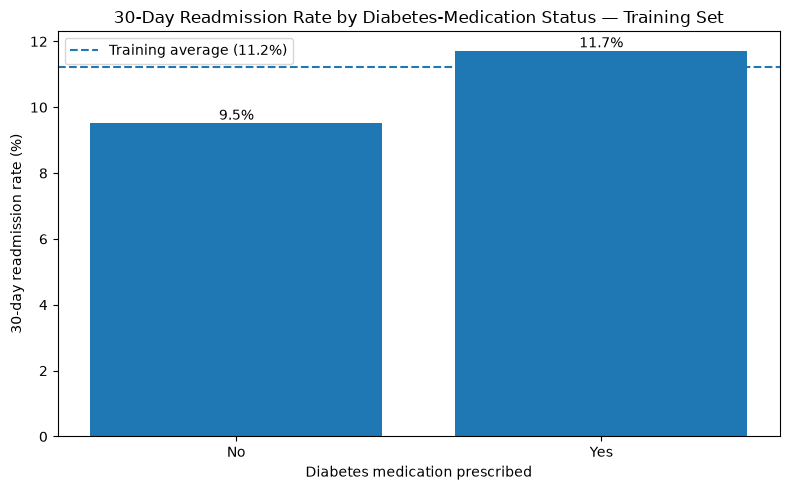

In [71]:
# Visualize readmission prevalence by diabetes-medication status

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    diabetes_med_analysis["diabetesMed"].astype(str),
    diabetes_med_analysis["readmission_pct"],
)

ax.axhline(
    positive_rate * 100,
    linestyle="--",
    linewidth=1.5,
    label=f"Training average ({positive_rate:.1%})",
)

for bar, rate in zip(
    bars,
    diabetes_med_analysis["readmission_pct"],
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{rate:.1f}%",
        ha="center",
        va="bottom",
    )

ax.set_title("30-Day Readmission Rate by Diabetes-Medication Status — Training Set")
ax.set_xlabel("Diabetes medication prescribed")
ax.set_ylabel("30-day readmission rate (%)")
ax.legend()

plt.tight_layout()
plt.show()

In [72]:
# Joint treatment-management analysis:
# medication change × diabetes-medication status

treatment_management_analysis = (
    df_train.groupby(
        ["diabetesMed", "change"],
        observed=True,
    )
    .agg(
        encounters=(TARGET, "size"),
        readmissions=(TARGET, "sum"),
        readmission_rate=(TARGET, "mean"),
    )
    .reset_index()
)

treatment_management_analysis["population_pct"] = (
    treatment_management_analysis["encounters"] / len(df_train) * 100
)

treatment_management_analysis["readmission_pct"] = (
    treatment_management_analysis["readmission_rate"] * 100
)

assert treatment_management_analysis["encounters"].sum() == len(df_train)
assert treatment_management_analysis["readmissions"].sum() == df_train[TARGET].sum()

treatment_management_analysis[
    [
        "diabetesMed",
        "change",
        "encounters",
        "population_pct",
        "readmissions",
        "readmission_pct",
    ]
].sort_values("readmission_pct")

,diabetesMed,change,encounters,population_pct,readmissions,readmission_pct
0,No,No,16407,22.9404,1562,9.5203
2,Yes,No,22112,30.9172,2547,11.5186
1,Yes,Ch,33001,46.1423,3912,11.8542


In [73]:
# Print joint treatment-management results clearly

print("Diabetes medication × medication change")
print("-" * 65)

for _, row in treatment_management_analysis.iterrows():
    print(
        f"diabetesMed={row['diabetesMed']:<3} | "
        f"change={row['change']:<2} | "
        f"encounters={int(row['encounters']):>6,} | "
        f"readmissions={int(row['readmissions']):>5,} | "
        f"rate={row['readmission_pct']:>5.1f}%"
    )

# Print diabetes-medication status results clearly

print("\nDiabetes medication status")
print("-" * 65)

for _, row in diabetes_med_analysis.iterrows():
    print(
        f"diabetesMed={row['diabetesMed']:<3} | "
        f"encounters={int(row['encounters']):>6,} | "
        f"readmissions={int(row['readmissions']):>5,} | "
        f"rate={row['readmission_pct']:>5.1f}%"
    )

Diabetes medication × medication change
-----------------------------------------------------------------
diabetesMed=No  | change=No | encounters=16,407 | readmissions=1,562 | rate=  9.5%
diabetesMed=Yes | change=Ch | encounters=33,001 | readmissions=3,912 | rate= 11.9%
diabetesMed=Yes | change=No | encounters=22,112 | readmissions=2,547 | rate= 11.5%

Diabetes medication status
-----------------------------------------------------------------
diabetesMed=No  | encounters=16,407 | readmissions=1,562 | rate=  9.5%
diabetesMed=Yes | encounters=55,113 | readmissions=6,459 | rate= 11.7%


### 3F.5 Treatment-management interpretation

Diabetes-medication status showed a clearer descriptive relationship with
30-day readmission than medication-change status alone. Encounters without
diabetes medication had a 9.5% readmission rate, compared with 11.5% among
encounters receiving diabetes medication without a documented change and
11.9% among encounters receiving diabetes medication with a documented
change.

The joint analysis also showed that medication-change status is structurally
related to diabetes-medication use: no encounters had a recorded diabetes
medication change while `diabetesMed` was `No`. Consequently, the marginal
association observed for `change` partly reflects differences in diabetes
medication status rather than an independent treatment-change effect.

Among encounters receiving diabetes medication, the difference between an
unchanged and changed regimen was comparatively small (11.5% versus 11.9%).
The larger separation occurred between encounters with and without diabetes
medication (approximately 11.7% versus 9.5% overall).

These patterns should be interpreted as descriptive associations rather than
causal treatment effects. Diabetes-medication use and treatment modification
may reflect underlying disease severity, treatment requirements, or other
clinical complexity. Both variables remain candidates for downstream
modeling, although their structural relationship should be considered during
feature engineering and interpretation.

## 3G — Encounter Pathway & Disposition

Admission pathway and discharge disposition may capture important differences
in encounter acuity, referral patterns, care transitions, and post-discharge
risk. This section evaluates admission type, admission source, and discharge
disposition in relation to 30-day readmission while considering category
sparsity, clinical interpretation, and potential target leakage.

### 3G.1 Admission Type

Admission type describes the broad pathway or urgency associated with the
hospital encounter. Differences across emergency, urgent, elective, and
other admission categories may reflect underlying acuity and therefore may
be associated with subsequent 30-day readmission.

The analysis first examines the original admission-type identifiers before
making any decisions about category consolidation or downstream feature
engineering.

In [74]:
# Inspect available encounter-pathway and disposition columns

pathway_keywords = [
    "admission",
    "admit",
    "source",
    "discharge",
    "disposition",
]

pathway_columns = [
    col
    for col in df_train.columns
    if any(keyword in col.lower() for keyword in pathway_keywords)
]

print("Encounter pathway / disposition candidate columns")
print("-" * 60)

for col in pathway_columns:
    print(col)

Encounter pathway / disposition candidate columns
------------------------------------------------------------
readmitted
readmitted_30d
admission_type_description
discharge_disposition_description
admission_source_description


In [75]:
# Inspect all training columns if needed

print(f"Total training features: {df_train.shape[1]}")
print("-" * 60)

for i, col in enumerate(df_train.columns, start=1):
    print(f"{i:>2}. {col}")

Total training features: 54
------------------------------------------------------------
 1. encounter_id
 2. patient_nbr
 3. readmitted
 4. readmitted_30d
 5. race
 6. gender
 7. age
 8. time_in_hospital
 9. payer_code
10. medical_specialty
11. num_lab_procedures
12. num_procedures
13. num_medications
14. number_outpatient
15. number_emergency
16. number_inpatient
17. diag_1
18. diag_2
19. diag_3
20. number_diagnoses
21. max_glu_serum
22. A1Cresult
23. metformin
24. repaglinide
25. nateglinide
26. chlorpropamide
27. glimepiride
28. acetohexamide
29. glipizide
30. glyburide
31. tolbutamide
32. pioglitazone
33. rosiglitazone
34. acarbose
35. miglitol
36. troglitazone
37. tolazamide
38. insulin
39. glyburide-metformin
40. glipizide-metformin
41. glimepiride-pioglitazone
42. metformin-rosiglitazone
43. metformin-pioglitazone
44. change
45. diabetesMed
46. admission_type_description
47. discharge_disposition_description
48. admission_source_description
49. prior_outpatient_group
50. diagno

In [76]:
# Inspect admission-type categories in the training set

ADMISSION_TYPE = "admission_type_description"

print("Admission type")
print("-" * 65)

print(f"Training encounters: {len(df_train):,}")
print(f"Unique admission types: " f"{df_train[ADMISSION_TYPE].nunique(dropna=False)}")
print(f"Missing values: " f"{df_train[ADMISSION_TYPE].isna().sum():,}")

print("\nAdmission-type distribution:")
print(df_train[ADMISSION_TYPE].value_counts(dropna=False))

Admission type
-----------------------------------------------------------------
Training encounters: 71,520
Unique admission types: 8
Missing values: 0

Admission-type distribution:
admission_type_description
Emergency        38013
Elective         13133
Urgent           12982
Unknown           3735
Not Available     3404
Not Mapped         230
Trauma Center       14
Newborn              9
Name: count, dtype: int64


In [77]:
# Summarize 30-day readmission by admission type

admission_type_analysis = (
    df_train.groupby(ADMISSION_TYPE, observed=True, dropna=False)
    .agg(
        encounters=(TARGET, "size"),
        readmissions=(TARGET, "sum"),
        readmission_rate=(TARGET, "mean"),
    )
    .reset_index()
)

admission_type_analysis["population_pct"] = (
    admission_type_analysis["encounters"] / len(df_train) * 100
)

admission_type_analysis["readmission_pct"] = (
    admission_type_analysis["readmission_rate"] * 100
)

# Validation
assert admission_type_analysis["encounters"].sum() == len(df_train)
assert admission_type_analysis["readmissions"].sum() == df_train[TARGET].sum()

admission_type_analysis = admission_type_analysis.sort_values(
    "encounters",
    ascending=False,
).reset_index(drop=True)

admission_type_analysis[
    [
        ADMISSION_TYPE,
        "encounters",
        "population_pct",
        "readmissions",
        "readmission_pct",
    ]
]

,admission_type_description,encounters,population_pct,readmissions,readmission_pct
0,Emergency,38013,53.1502,4395,11.5618
1,Elective,13133,18.3627,1380,10.5079
2,Urgent,12982,18.1516,1450,11.1693
3,Unknown,3735,5.2223,409,10.9505
4,Not Available,3404,4.7595,362,10.6345
5,Not Mapped,230,0.3216,24,10.4348
6,Trauma Center,14,0.0196,0,0.0000
7,Newborn,9,0.0126,1,11.1111


In [78]:
# Print admission-type results clearly

print("30-day readmission by admission type")
print("-" * 85)

for _, row in admission_type_analysis.iterrows():
    print(
        f"{str(row[ADMISSION_TYPE]):<25} | "
        f"encounters={int(row['encounters']):>6,} | "
        f"population={row['population_pct']:>5.1f}% | "
        f"readmissions={int(row['readmissions']):>5,} | "
        f"rate={row['readmission_pct']:>5.1f}%"
    )

30-day readmission by admission type
-------------------------------------------------------------------------------------
Emergency                 | encounters=38,013 | population= 53.2% | readmissions=4,395 | rate= 11.6%
Elective                  | encounters=13,133 | population= 18.4% | readmissions=1,380 | rate= 10.5%
Urgent                    | encounters=12,982 | population= 18.2% | readmissions=1,450 | rate= 11.2%
Unknown                   | encounters= 3,735 | population=  5.2% | readmissions=  409 | rate= 11.0%
Not Available             | encounters= 3,404 | population=  4.8% | readmissions=  362 | rate= 10.6%
Not Mapped                | encounters=   230 | population=  0.3% | readmissions=   24 | rate= 10.4%
Trauma Center             | encounters=    14 | population=  0.0% | readmissions=    0 | rate=  0.0%
Newborn                   | encounters=     9 | population=  0.0% | readmissions=    1 | rate= 11.1%


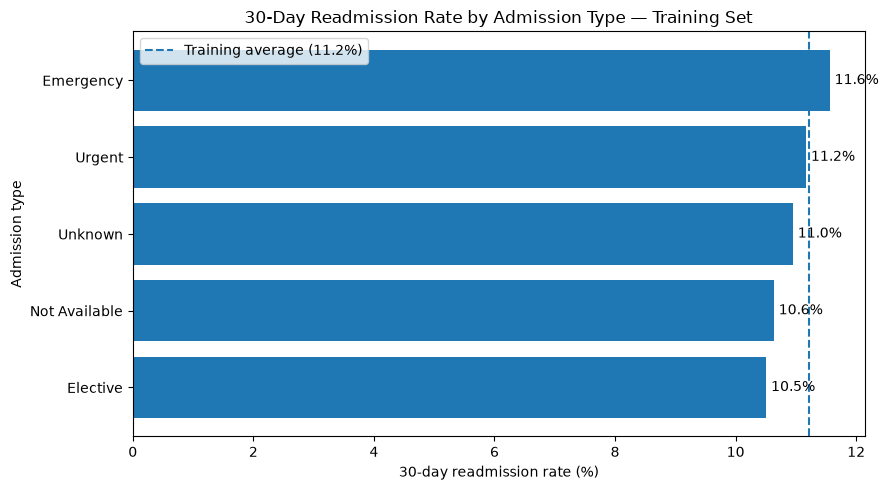

In [79]:
# Restrict visualization to adequately represented admission types

MIN_ENCOUNTERS = 500

admission_type_plot = (
    admission_type_analysis[admission_type_analysis["encounters"] >= MIN_ENCOUNTERS]
    .sort_values("readmission_pct")
    .copy()
)

fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.barh(
    admission_type_plot[ADMISSION_TYPE],
    admission_type_plot["readmission_pct"],
)

ax.axvline(
    positive_rate * 100,
    linestyle="--",
    linewidth=1.5,
    label=f"Training average ({positive_rate:.1%})",
)

for bar, rate in zip(
    bars,
    admission_type_plot["readmission_pct"],
):
    ax.text(
        bar.get_width() + 0.08,
        bar.get_y() + bar.get_height() / 2,
        f"{rate:.1f}%",
        va="center",
    )

ax.set_title("30-Day Readmission Rate by Admission Type — Training Set")
ax.set_xlabel("30-day readmission rate (%)")
ax.set_ylabel("Admission type")
ax.legend()

plt.tight_layout()
plt.show()

#### Admission-type interpretation

Emergency admissions accounted for 53.2% of training encounters and had a
30-day readmission rate of 11.6%, compared with 11.2% for urgent admissions
and 10.5% for elective admissions.

Despite differences in admission urgency, readmission prevalence varied only
modestly across the major admission-type categories. Emergency encounters
showed somewhat higher readmission prevalence than elective encounters, but
the approximately 1.1-percentage-point separation was substantially smaller
than the gradients observed for prior inpatient and emergency utilization.

Several admission-type categories were extremely sparse. Trauma Center and
Newborn admissions contained only 14 and 9 encounters, respectively, so
their observed readmission rates are not interpreted as stable estimates.
Unknown and unavailable categories were retained descriptively because they
represented nontrivial portions of the training population.

Overall, admission type appears to provide limited univariate discrimination
for 30-day readmission, although it may still contribute useful contextual
information in multivariable modeling and through interactions with other
clinical and utilization features.

### 3G.2 Admission Source

Admission source describes the pathway through which a patient entered the
hospital encounter, such as emergency services, physician referral, transfer,
or other referral mechanisms. These pathways may reflect differences in
clinical acuity, continuity of care, and healthcare utilization patterns that
could be associated with subsequent 30-day readmission.

In [80]:
# Inspect admission-source categories

ADMISSION_SOURCE = "admission_source_description"

print("Admission source")
print("-" * 65)

print(f"Training encounters: {len(df_train):,}")
print(
    f"Unique admission sources: " f"{df_train[ADMISSION_SOURCE].nunique(dropna=False)}"
)
print(f"Missing values: " f"{df_train[ADMISSION_SOURCE].isna().sum():,}")

print("\nAdmission-source distribution:")
print(df_train[ADMISSION_SOURCE].value_counts(dropna=False))

Admission source
-----------------------------------------------------------------
Training encounters: 71,520
Unique admission sources: 17
Missing values: 0

Admission-source distribution:
admission_source_description
Emergency Room                                               40525
Physician Referral                                           20630
Unknown                                                       4828
Transfer from a hospital                                      2240
Transfer from another health care facility                    1627
Clinic Referral                                                743
Transfer from a Skilled Nursing Facility (SNF)                 576
HMO Referral                                                   128
Not Mapped                                                     107
Not Available                                                   84
Court/Law Enforcement                                           12
Transfer from hospital inpt/same fac reslt i

In [81]:
# Summarize 30-day readmission by admission source

admission_source_analysis = (
    df_train.groupby(ADMISSION_SOURCE, observed=True, dropna=False)
    .agg(
        encounters=(TARGET, "size"),
        readmissions=(TARGET, "sum"),
        readmission_rate=(TARGET, "mean"),
    )
    .reset_index()
)

admission_source_analysis["population_pct"] = (
    admission_source_analysis["encounters"] / len(df_train) * 100
)

admission_source_analysis["readmission_pct"] = (
    admission_source_analysis["readmission_rate"] * 100
)

assert admission_source_analysis["encounters"].sum() == len(df_train)
assert admission_source_analysis["readmissions"].sum() == df_train[TARGET].sum()

admission_source_analysis = admission_source_analysis.sort_values(
    "encounters",
    ascending=False,
).reset_index(drop=True)

print("30-day readmission by admission source")
print("-" * 100)

for _, row in admission_source_analysis.iterrows():
    print(
        f"{str(row[ADMISSION_SOURCE]):<35} | "
        f"encounters={int(row['encounters']):>6,} | "
        f"population={row['population_pct']:>5.1f}% | "
        f"readmissions={int(row['readmissions']):>5,} | "
        f"rate={row['readmission_pct']:>5.1f}%"
    )

30-day readmission by admission source
----------------------------------------------------------------------------------------------------
Emergency Room                      | encounters=40,525 | population= 56.7% | readmissions=4,779 | rate= 11.8%
Physician Referral                  | encounters=20,630 | population= 28.8% | readmissions=2,178 | rate= 10.6%
Unknown                             | encounters= 4,828 | population=  6.8% | readmissions=  509 | rate= 10.5%
Transfer from a hospital            | encounters= 2,240 | population=  3.1% | readmissions=  217 | rate=  9.7%
Transfer from another health care facility | encounters= 1,627 | population=  2.3% | readmissions=  148 | rate=  9.1%
Clinic Referral                     | encounters=   743 | population=  1.0% | readmissions=   70 | rate=  9.4%
Transfer from a Skilled Nursing Facility (SNF) | encounters=   576 | population=  0.8% | readmissions=   72 | rate= 12.5%
HMO Referral                        | encounters=   128 | populat

In [82]:
# Consolidate admission sources into analytically meaningful groups


def group_admission_source(source):
    if source == "Emergency Room":
        return "Emergency Room"

    elif source == "Physician Referral":
        return "Physician Referral"

    elif source in [
        "Transfer from a hospital",
        "Transfer from another health care facility",
        "Transfer from a Skilled Nursing Facility (SNF)",
        "Transfer from hospital inpt/same fac reslt in a sep claim",
        "Transfer from critical access hospital",
        "Transfer from Ambulatory Surgery Center",
    ]:
        return "Facility Transfer"

    elif source in [
        "Clinic Referral",
        "HMO Referral",
    ]:
        return "Other Referral"

    elif source in [
        "Unknown",
        "Not Mapped",
        "Not Available",
    ]:
        return "Unknown / Unavailable"

    else:
        return "Other"


df_train["admission_source_group"] = df_train[ADMISSION_SOURCE].apply(
    group_admission_source
)


admission_source_group_analysis = (
    df_train.groupby("admission_source_group", observed=True, dropna=False)
    .agg(
        encounters=(TARGET, "size"),
        readmissions=(TARGET, "sum"),
        readmission_rate=(TARGET, "mean"),
    )
    .reset_index()
)

admission_source_group_analysis["population_pct"] = (
    admission_source_group_analysis["encounters"] / len(df_train) * 100
)

admission_source_group_analysis["readmission_pct"] = (
    admission_source_group_analysis["readmission_rate"] * 100
)

# Validate complete coverage
assert admission_source_group_analysis["encounters"].sum() == len(df_train)
assert admission_source_group_analysis["readmissions"].sum() == df_train[TARGET].sum()

admission_source_group_analysis = admission_source_group_analysis.sort_values(
    "encounters", ascending=False
).reset_index(drop=True)

admission_source_group_analysis[
    [
        "admission_source_group",
        "encounters",
        "population_pct",
        "readmissions",
        "readmission_pct",
    ]
].round(2)

,admission_source_group,encounters,population_pct,readmissions,readmission_pct
0,Emergency Room,40525,56.6600,4779,11.7900
1,Physician Referral,20630,28.8500,2178,10.5600
2,Unknown / Unavailable,5019,7.0200,535,10.6600
3,Facility Transfer,4453,6.2300,439,9.8600
4,Other Referral,871,1.2200,88,10.1000
5,Other,22,0.0300,2,9.0900


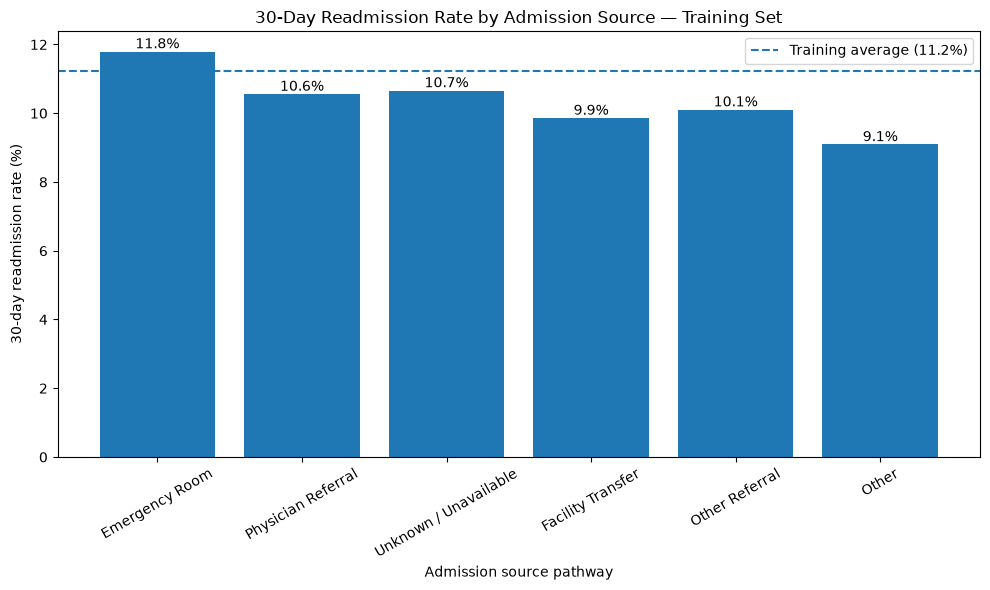

In [83]:
# Visualize readmission prevalence across consolidated admission sources

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(
    admission_source_group_analysis["admission_source_group"],
    admission_source_group_analysis["readmission_pct"],
)

ax.axhline(
    positive_rate * 100,
    linestyle="--",
    linewidth=1.5,
    label=f"Training average ({positive_rate:.1%})",
)

for bar, rate in zip(
    bars,
    admission_source_group_analysis["readmission_pct"],
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{rate:.1f}%",
        ha="center",
        va="bottom",
    )

ax.set_title("30-Day Readmission Rate by Admission Source — Training Set")
ax.set_xlabel("Admission source pathway")
ax.set_ylabel("30-day readmission rate (%)")

ax.tick_params(axis="x", rotation=30)
ax.legend()

plt.tight_layout()
plt.show()

### 3G.3 Discharge Disposition

Discharge disposition describes the patient's destination or status at the end
of the index encounter and may capture important differences in post-acute care
needs, clinical severity, and transition-of-care complexity.

Because discharge disposition is determined near or at the end of the encounter,
its suitability as a predictive feature depends on the intended prediction
timestamp. Categories involving death, hospice, or other terminal dispositions
also require special consideration because subsequent 30-day readmission may
not represent a meaningful or observable outcome for these patients.

The analysis therefore first examines the original discharge-disposition
structure, category prevalence, and readmission rates before determining
appropriate exclusions or consolidation for downstream modeling.

In [84]:
# Inspect discharge-disposition structure in the training set

DISCHARGE = "discharge_disposition_description"

print("Discharge disposition")
print("-" * 60)

print(f"Training encounters: {len(df_train):,}")
print(
    f"Unique discharge dispositions: " f"{df_train[DISCHARGE].nunique(dropna=False):,}"
)
print(f"Missing values: " f"{df_train[DISCHARGE].isna().sum():,}")

print("\nDischarge-disposition distribution:")
print(df_train[DISCHARGE].value_counts(dropna=False))

Discharge disposition
------------------------------------------------------------
Training encounters: 71,520
Unique discharge dispositions: 26
Missing values: 0

Discharge-disposition distribution:
discharge_disposition_description
Discharged to home                                                                                           42257
Discharged/transferred to SNF                                                                                 9869
Discharged/transferred to home with home health service                                                       9072
Unknown                                                                                                       2565
Discharged/transferred to another short term hospital                                                         1513
Discharged/transferred to another rehab fac including rehab units of a hospital .                             1384
Expired                                                                     

In [85]:
# Summarize 30-day readmission by discharge disposition

discharge_analysis = (
    df_train.groupby(
        DISCHARGE,
        observed=True,
        dropna=False,
    )
    .agg(
        encounters=(TARGET, "size"),
        readmissions=(TARGET, "sum"),
        readmission_rate=(TARGET, "mean"),
    )
    .reset_index()
)

discharge_analysis["population_pct"] = (
    discharge_analysis["encounters"] / len(df_train) * 100
)

discharge_analysis["readmission_pct"] = discharge_analysis["readmission_rate"] * 100

# Validate complete coverage
assert discharge_analysis["encounters"].sum() == len(df_train)
assert discharge_analysis["readmissions"].sum() == df_train[TARGET].sum()

discharge_analysis = discharge_analysis.sort_values(
    "encounters", ascending=False
).reset_index(drop=True)

discharge_analysis[
    [
        DISCHARGE,
        "encounters",
        "population_pct",
        "readmissions",
        "readmission_pct",
    ]
].round(2)

,discharge_disposition_description,encounters,population_pct,readmissions,readmission_pct
0,Discharged to home,42257,59.0800,3935,9.3100
1,Discharged/transferred to SNF,9869,13.8000,1487,15.0700
2,Discharged/transferred to home with home healt...,9072,12.6800,1150,12.6800
3,Unknown,2565,3.5900,315,12.2800
4,Discharged/transferred to another short term h...,1513,2.1200,243,16.0600
5,Discharged/transferred to another rehab fac in...,1384,1.9400,378,27.3100
6,Expired,1172,1.6400,0,0.0000
7,Discharged/transferred to another type of inpa...,838,1.1700,176,21.0000
8,Not Mapped,681,0.9500,68,9.9900
9,Discharged/transferred to ICF,593,0.8300,75,12.6500


In [86]:
# Print complete discharge-disposition results for interpretation

print("30-day readmission by discharge disposition")
print("-" * 115)

for _, row in discharge_analysis.iterrows():
    print(
        f"{str(row[DISCHARGE])[:65]:65} | "
        f"n={int(row['encounters']):>6,} | "
        f"population={row['population_pct']:>5.1f}% | "
        f"readmissions={int(row['readmissions']):>5,} | "
        f"rate={row['readmission_pct']:>5.1f}%"
    )

30-day readmission by discharge disposition
-------------------------------------------------------------------------------------------------------------------
Discharged to home                                                | n=42,257 | population= 59.1% | readmissions=3,935 | rate=  9.3%
Discharged/transferred to SNF                                     | n= 9,869 | population= 13.8% | readmissions=1,487 | rate= 15.1%
Discharged/transferred to home with home health service           | n= 9,072 | population= 12.7% | readmissions=1,150 | rate= 12.7%
Unknown                                                           | n= 2,565 | population=  3.6% | readmissions=  315 | rate= 12.3%
Discharged/transferred to another short term hospital             | n= 1,513 | population=  2.1% | readmissions=  243 | rate= 16.1%
Discharged/transferred to another rehab fac including rehab units | n= 1,384 | population=  1.9% | readmissions=  378 | rate= 27.3%
Expired                                         

In [87]:
# Consolidate discharge dispositions into clinically interpretable pathways


def group_discharge_disposition(disposition):
    disposition = str(disposition)

    if disposition == "Discharged to home":
        return "Home"

    elif disposition == "Discharged/transferred to home with home health service":
        return "Home Health"

    elif disposition == "Discharged/transferred to SNF":
        return "Skilled Nursing Facility"

    elif "rehab" in disposition.lower():
        return "Rehabilitation"

    elif disposition in [
        "Discharged/transferred to another short term hospital",
        "Discharged/transferred to another type of inpatient care institution",
        "Discharged/transferred to ICF",
        "Discharged/transferred to a long term care hospital.",
        "Discharged/transferred to a psychiatric hospital of psychiatric distinct part unit of a hospital",
        "Discharged/transferred within this institution to Medicare approved swing bed",
        "Discharged/transferred to a nursing facility certified under Medicaid but not certified under Medicare",
        "Admitted as an inpatient to this hospital",
    ]:
        return "Institutional / Inpatient Care"

    elif "expired" in disposition.lower() or "hospice" in disposition.lower():
        return "Hospice / Expired"

    elif disposition in [
        "Unknown",
        "Not Mapped",
    ]:
        return "Unknown / Unmapped"

    else:
        return "Other"


df_train["discharge_group"] = df_train[DISCHARGE].apply(group_discharge_disposition)

discharge_group_analysis = (
    df_train.groupby(
        "discharge_group",
        observed=True,
        dropna=False,
    )
    .agg(
        encounters=(TARGET, "size"),
        readmissions=(TARGET, "sum"),
        readmission_rate=(TARGET, "mean"),
    )
    .reset_index()
)

discharge_group_analysis["population_pct"] = (
    discharge_group_analysis["encounters"] / len(df_train) * 100
)

discharge_group_analysis["readmission_pct"] = (
    discharge_group_analysis["readmission_rate"] * 100
)

assert discharge_group_analysis["encounters"].sum() == len(df_train)
assert discharge_group_analysis["readmissions"].sum() == df_train[TARGET].sum()

discharge_group_analysis = discharge_group_analysis.sort_values(
    "encounters", ascending=False
).reset_index(drop=True)

discharge_group_analysis[
    [
        "discharge_group",
        "encounters",
        "population_pct",
        "readmissions",
        "readmission_pct",
    ]
].round(2)

,discharge_group,encounters,population_pct,readmissions,readmission_pct
0,Home,42257,59.0800,3935,9.3100
1,Skilled Nursing Facility,9869,13.8000,1487,15.0700
2,Home Health,9072,12.6800,1150,12.6800
3,Institutional / Inpatient Care,3297,4.6100,542,16.4400
4,Unknown / Unmapped,3246,4.5400,383,11.8000
5,Hospice / Expired,1723,2.4100,27,1.5700
6,Rehabilitation,1384,1.9400,378,27.3100
7,Other,672,0.9400,119,17.7100


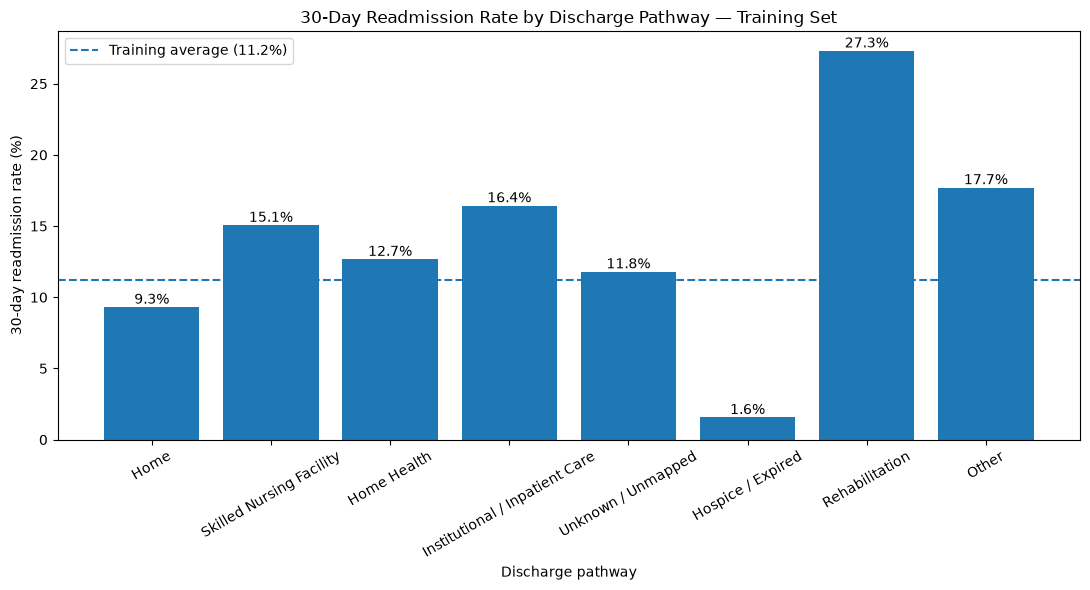

In [88]:
# Visualize consolidated discharge pathways

fig, ax = plt.subplots(figsize=(11, 6))

bars = ax.bar(
    discharge_group_analysis["discharge_group"],
    discharge_group_analysis["readmission_pct"],
)

ax.axhline(
    positive_rate * 100,
    linestyle="--",
    linewidth=1.5,
    label=f"Training average ({positive_rate:.1%})",
)

for bar, rate in zip(
    bars,
    discharge_group_analysis["readmission_pct"],
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{rate:.1f}%",
        ha="center",
        va="bottom",
    )

ax.set_title("30-Day Readmission Rate by Discharge Pathway — Training Set")
ax.set_xlabel("Discharge pathway")
ax.set_ylabel("30-day readmission rate (%)")

ax.tick_params(axis="x", rotation=30)
ax.legend()

plt.tight_layout()
plt.show()

### 3G.3 Discharge-disposition interpretation

Discharge disposition shows one of the clearest descriptive relationships with 30-day readmission observed in the training data. Encounters discharged directly home had a readmission rate of approximately **9.3%**, below the overall training prevalence of approximately **11.2%**. Readmission prevalence increased among patients requiring additional post-discharge support, including **home health (12.7%)**, **skilled nursing facilities (15.1%)**, and broader **institutional/inpatient care (16.4%)**.

The strongest adequately represented signal was observed among patients discharged to **rehabilitation facilities**, with a readmission rate of approximately **27.3%**. This pattern is clinically plausible because discharge destination may encode residual illness severity, functional impairment, care-transition complexity, and the need for continued post-acute treatment.

The very low observed rate among the **hospice/expired** group should not be interpreted as a protective effect. Patients who expire during the index encounter cannot subsequently experience an ordinary 30-day readmission, while hospice pathways may also reflect competing mortality risk. These dispositions therefore require special consideration during cohort definition and feature engineering to avoid introducing structural negative outcomes or misleading predictive signal.

Overall, discharge disposition appears substantially more informative descriptively than admission type or admission source and should be retained as an important candidate for downstream feature engineering. However, its availability at the intended prediction time must be considered explicitly: if the model is intended to generate risk predictions before discharge disposition is known, using this variable would constitute target-time leakage.

## 3G.4 Encounter Pathway Synthesis

The encounter-pathway variables differ substantially in their descriptive association with 30-day readmission.

**Admission type** showed relatively modest separation across the major categories. Emergency admissions had somewhat higher readmission prevalence than elective encounters, but the differences were small relative to several clinical-complexity variables examined earlier.

**Admission source** provided additional pathway information. Emergency-room admissions showed moderately elevated readmission prevalence, while physician referrals and facility transfers were closer to or below the overall training average after category consolidation. The magnitude of separation remained modest.

**Discharge disposition**, in contrast, demonstrated a pronounced risk gradient. Patients discharged directly home had comparatively low readmission prevalence, while those requiring home health, skilled nursing, institutional care, or rehabilitation showed progressively higher observed rates. Rehabilitation discharge was particularly notable.

These findings suggest that encounter pathway alone does not uniformly predict readmission risk; rather, the strongest descriptive information appears near the **post-acute transition of care**. This is clinically plausible because discharge destination can reflect accumulated information about illness severity, functional status, treatment response, and continuing care requirements.

For downstream modeling:

- Admission type and admission source remain reasonable candidate predictors but appear unlikely to dominate model performance independently.
- Consolidated categories may be preferable to raw administrative codes because several original categories are extremely sparse.
- Discharge disposition is a potentially strong predictor but must be evaluated against the intended prediction timestamp to prevent target-time leakage.
- Hospice and expired dispositions require explicit cohort-policy consideration because mortality creates a competing event for 30-day readmission.
- All associations observed here are descriptive and should not be interpreted as causal effects.

# 3H — EDA Synthesis & Modeling Implications

The exploratory analysis identified several clinically and operationally meaningful patterns associated with 30-day readmission in the training population. Rather than treating every available variable as equally informative, this section synthesizes the evidence developed throughout the EDA and translates it into explicit decisions for downstream feature engineering and predictive modeling.

The objectives of this synthesis are to:

1. distinguish the strongest descriptive signals from weaker or unstable relationships;
2. identify variables that may encode clinical complexity, prior utilization, treatment burden, or care-transition risk;
3. document data-quality, sparsity, competing-risk, and target-leakage concerns;
4. define candidate transformations and category consolidations;
5. establish which variables should be retained, transformed, conditionally used, or excluded from modeling; and
6. provide a reproducible analytical bridge from exploratory analysis to feature engineering.

All relationships summarized below are **descriptive associations within the training data**. They should not be interpreted as causal effects, and their predictive contribution must ultimately be evaluated using held-out validation data.

## 3H.1 Strongest Descriptive Signals

Several variables produced clear and clinically plausible separation in observed 30-day readmission prevalence.

### Prior inpatient utilization

Prior inpatient utilization emerged as one of the most important utilization-history signals. Increasing recent inpatient use was associated with substantially higher readmission prevalence, consistent with the interpretation that repeated hospitalization captures persistent disease burden, instability, and unresolved care needs.

This variable should receive high priority during feature engineering. Both the original count and clinically interpretable utilization groupings should be considered.

### Discharge disposition

Discharge pathway produced one of the largest descriptive gradients observed during EDA. Patients discharged directly home had comparatively low readmission prevalence, whereas patients requiring home health, skilled nursing, institutional care, or rehabilitation showed substantially higher rates.

This makes discharge disposition a potentially powerful predictor of post-acute risk. However, its inclusion depends on the intended prediction timestamp because discharge information may not be available when an admission-time model generates its prediction.

### Medication burden

The number of documented medications showed a meaningful treatment-complexity gradient. Readmission prevalence increased from approximately **9.2% among encounters with 1–10 medications** to **11.5% for 11–20 medications** and **12.9% for 21–30 medications**, remaining elevated at approximately **12.3% for 31+ medications**.

Medication burden therefore appears useful as a proxy for treatment complexity and possibly multimorbidity, although it should not be interpreted as a causal effect of medication exposure.

### Diagnostic burden

Increasing numbers of documented diagnoses were generally associated with higher readmission prevalence. Sparse extreme diagnosis counts produced unstable estimates, but broader diagnostic-burden groupings revealed a clearer pattern.

This supports retaining diagnostic burden as a measure of clinical complexity while avoiding overinterpretation of rare individual count levels.

### Primary-diagnosis clinical family

Primary diagnosis families demonstrated clinically meaningful variation in readmission prevalence. Several diagnostic families were above the overall training baseline, while others were consistently below it.

Consolidating raw ICD-9 codes into clinically interpretable families substantially reduced dimensionality while preserving useful diagnostic information and should therefore be carried forward into feature engineering.

## 3H.2 Moderate and Contextual Signals

Several variables demonstrated meaningful but comparatively modest differences in readmission prevalence. These features remain reasonable modeling candidates, particularly because multivariable models may identify useful interactions that are not obvious from univariate EDA.

### Diabetes medication status

Encounters in which diabetes medication was prescribed had an observed readmission prevalence of approximately **11.7%**, compared with approximately **9.5%** among encounters without diabetes medication.

The difference likely reflects underlying diabetes severity, treatment requirements, or broader clinical complexity rather than a direct medication effect.

### Medication change during the encounter

Encounters involving a medication change showed approximately **11.9%** readmission prevalence compared with approximately **10.7%** when no medication change occurred.

The difference is modest but directionally consistent with the possibility that active treatment modification identifies patients requiring greater disease-management intervention.

### Admission source

Admission source showed moderate descriptive separation after sparse categories were consolidated. Emergency-room admissions had approximately **11.8%** readmission prevalence, modestly above the overall training average, while several other pathways were closer to or below baseline.

Admission source therefore appears useful primarily as contextual information about the pathway into hospitalization.

### Admission type

Emergency, urgent, and elective admission categories exhibited relatively small differences in observed readmission prevalence. Admission type may still contribute predictive information when combined with clinical severity, utilization history, diagnosis, and treatment variables, but it does not appear to be a dominant standalone discriminator.

### Procedure burden

Procedure counts showed limited evidence of a monotonic relationship with readmission. Most categories remained relatively close to the overall training prevalence, with some higher procedure counts showing lower observed rates.

The raw procedure count should therefore remain available as a candidate predictor, but the EDA does not support treating greater procedure burden as inherently indicative of higher readmission risk.

## 3H.3 Weak, Sparse, and Unstable Signals

Not every apparent difference observed during EDA should be treated as reliable predictive structure.

Several variables contained categories or numerical values represented by very small numbers of encounters. These sparse groups sometimes produced extreme readmission percentages, including rates approaching 0% or 100%. Such estimates primarily reflect small denominators and should not be interpreted as stable risk relationships.

Examples include:

- extreme medication counts;
- extreme diagnosis counts;
- rare admission-source categories;
- rare admission-type categories;
- uncommon discharge dispositions; and
- infrequent diagnosis families or administrative classifications.

Feature engineering should therefore prioritize minimum-frequency thresholds, clinically sensible category consolidation, or explicit rare-category handling rather than preserving every raw category independently.

More broadly, weak univariate separation does not automatically justify excluding a feature. Variables with limited standalone association may still improve prediction through nonlinear relationships or interactions with other clinical and utilization characteristics. Final feature selection should therefore be based on validation performance rather than EDA magnitude alone.

## 3H.4 Data Quality, Leakage, and Modeling Risks

The EDA identified several issues that must be addressed explicitly before predictive modeling.

### Repeated patients

The dataset contains multiple encounters for some patients. Random encounter-level splitting could therefore place encounters from the same patient into both training and validation/test sets, allowing patient-specific history to cross dataset boundaries.

Downstream validation should evaluate patient-aware splitting or grouping strategies where appropriate.

### Prediction-time leakage

Feature eligibility depends on the intended prediction timestamp.

Variables known only during or near the end of hospitalization may be legitimate for a discharge-time readmission model but inappropriate for an admission-time model. Discharge disposition is the clearest example: it contains substantial descriptive signal but may constitute target-time leakage if the prediction is intended to occur before discharge planning is complete.

A formal feature-availability audit should therefore precede final model training.

### Competing mortality risk

Expired encounters and some hospice-related dispositions are structurally different from ordinary readmission-risk encounters. A patient who dies during the index hospitalization cannot subsequently experience a conventional 30-day readmission.

These observations require an explicit cohort-definition decision rather than allowing the model to learn mortality-associated structural negatives as though they represented ordinary low readmission risk.

### Sparse categorical levels

Several administrative and clinical variables contain rare categories with unstable outcome estimates. Raw one-hot encoding of every category could increase dimensionality and encourage overfitting.

Rare-level consolidation should be performed using rules learned from the training data and then applied unchanged to validation and test data.

### Administrative missingness

Values such as `Unknown`, `Not Available`, and `Not Mapped` may represent different data-generation mechanisms rather than ordinary random missingness.

These categories should not automatically be treated as equivalent without evaluating their semantic meaning and frequency.

### Class imbalance

Thirty-day readmission is the minority outcome in the training population, with prevalence of approximately **11.2%**.

Accuracy alone will therefore be an inadequate evaluation metric. Model assessment should emphasize discrimination and minority-class performance using metrics such as ROC-AUC, precision, recall/sensitivity, F1 score, and particularly precision-recall AUC where appropriate.

### Descriptive association versus causality

EDA identifies association, not causal effect. Higher readmission prevalence among patients with greater medication burden, post-acute care requirements, or particular diagnoses does not demonstrate that those characteristics cause readmission.

Interpretation of the final predictive model should preserve this distinction.

In [89]:
# 3H.5 Create EDA-to-modeling feature decision matrix

feature_decisions = pd.DataFrame(
    [
        {
            "domain": "Utilization",
            "feature": "number_inpatient",
            "eda_signal": "Strong",
            "proposed_treatment": "Retain count; evaluate grouped/nonlinear representation",
            "modeling_status": "High priority",
        },
        {
            "domain": "Utilization",
            "feature": "number_emergency",
            "eda_signal": "Moderate",
            "proposed_treatment": "Retain count; evaluate skew-aware transformation",
            "modeling_status": "Retain",
        },
        {
            "domain": "Utilization",
            "feature": "number_outpatient",
            "eda_signal": "Contextual",
            "proposed_treatment": "Retain count; evaluate interactions with prior utilization",
            "modeling_status": "Retain",
        },
        {
            "domain": "Clinical complexity",
            "feature": "number_diagnoses",
            "eda_signal": "Moderate",
            "proposed_treatment": "Retain numeric count; consider burden groups",
            "modeling_status": "Retain",
        },
        {
            "domain": "Diagnosis",
            "feature": "diag_1_family",
            "eda_signal": "Moderate",
            "proposed_treatment": "Use consolidated clinical families",
            "modeling_status": "Retain",
        },
        {
            "domain": "Diagnosis",
            "feature": "diag_2_family / diag_3_family",
            "eda_signal": "Contextual",
            "proposed_treatment": "Evaluate consolidated secondary/tertiary diagnosis features",
            "modeling_status": "Retain / evaluate",
        },
        {
            "domain": "Treatment complexity",
            "feature": "num_medications",
            "eda_signal": "Moderate",
            "proposed_treatment": "Retain numeric count; evaluate medication-burden grouping",
            "modeling_status": "High priority",
        },
        {
            "domain": "Treatment",
            "feature": "num_procedures",
            "eda_signal": "Weak / nonlinear",
            "proposed_treatment": "Retain numeric count; avoid assuming monotonic effect",
            "modeling_status": "Retain",
        },
        {
            "domain": "Treatment",
            "feature": "change",
            "eda_signal": "Modest",
            "proposed_treatment": "Binary/categorical encoding",
            "modeling_status": "Retain",
        },
        {
            "domain": "Treatment",
            "feature": "diabetesMed",
            "eda_signal": "Modest",
            "proposed_treatment": "Binary/categorical encoding",
            "modeling_status": "Retain",
        },
        {
            "domain": "Encounter pathway",
            "feature": "admission_type_description",
            "eda_signal": "Weak / modest",
            "proposed_treatment": "Consolidate rare categories",
            "modeling_status": "Retain",
        },
        {
            "domain": "Encounter pathway",
            "feature": "admission_source_description",
            "eda_signal": "Moderate",
            "proposed_treatment": "Use consolidated pathway groups",
            "modeling_status": "Retain",
        },
        {
            "domain": "Care transition",
            "feature": "discharge_disposition_description",
            "eda_signal": "Strong",
            "proposed_treatment": "Consolidate clinically similar pathways",
            "modeling_status": "Conditional — prediction-time audit",
        },
        {
            "domain": "Cohort definition",
            "feature": "Expired / hospice dispositions",
            "eda_signal": "Structural",
            "proposed_treatment": "Evaluate exclusion/competing-risk policy",
            "modeling_status": "Review before modeling",
        },
    ]
)

feature_decisions

,domain,feature,eda_signal,proposed_treatment,modeling_status
0,Utilization,number_inpatient,Strong,Retain count; evaluate grouped/nonlinear repre...,High priority
1,Utilization,number_emergency,Moderate,Retain count; evaluate skew-aware transformation,Retain
2,Utilization,number_outpatient,Contextual,Retain count; evaluate interactions with prior...,Retain
3,Clinical complexity,number_diagnoses,Moderate,Retain numeric count; consider burden groups,Retain
4,Diagnosis,diag_1_family,Moderate,Use consolidated clinical families,Retain
5,Diagnosis,diag_2_family / diag_3_family,Contextual,Evaluate consolidated secondary/tertiary diagn...,Retain / evaluate
6,Treatment complexity,num_medications,Moderate,Retain numeric count; evaluate medication-burd...,High priority
7,Treatment,num_procedures,Weak / nonlinear,Retain numeric count; avoid assuming monotonic...,Retain
8,Treatment,change,Modest,Binary/categorical encoding,Retain
9,Treatment,diabetesMed,Modest,Binary/categorical encoding,Retain


## 3H.6 EDA Conclusions and Transition to Feature Engineering

The exploratory analysis indicates that 30-day hospital readmission is associated with multiple dimensions of patient and encounter complexity rather than a single dominant characteristic.

The most compelling descriptive signals involve **prior healthcare utilization, diagnostic burden, medication burden, selected clinical diagnosis families, and post-acute discharge pathway**. In particular, repeated inpatient utilization and more intensive discharge destinations identify patient groups with substantially elevated observed readmission prevalence.

Other variables—including admission pathway, medication-management changes, diabetes-medication status, and procedure burden—show weaker or more contextual relationships but remain plausible contributors to multivariable prediction.

The analysis also identified several methodological constraints that materially affect model design. Sparse categories require consolidation, repeated patients require careful validation design, mortality-related dispositions require explicit cohort handling, and feature availability must be aligned with the intended prediction timestamp to prevent leakage.

Accordingly, the next stage of the project will move from descriptive exploration to reproducible feature engineering. The feature-engineering pipeline should:

1. establish the final modeling cohort and prediction timestamp;
2. separate predictor variables from identifiers and outcome-related fields;
3. implement patient-aware train/validation/test safeguards where appropriate;
4. consolidate sparse categorical variables using training-derived mappings;
5. encode clinically meaningful diagnosis families;
6. preserve and/or transform utilization, diagnostic, procedure, and medication-burden measures;
7. encode treatment-management indicators;
8. determine whether discharge disposition is eligible for the intended prediction use case;
9. construct preprocessing steps that can be fit exclusively on training data and applied unchanged to held-out data; and
10. prepare reproducible feature matrices for baseline and advanced predictive models.

The resulting models will be evaluated not only for overall discrimination but also for their ability to identify the minority readmission class, their calibration, their stability on held-out patients, and their clinical interpretability.

**EDA is therefore considered complete once these analytical decisions are documented and the notebook executes reproducibly from beginning to end.**